## Modelos de Clustering


El objetivo de esta etapa es segmentar las entidades financieras en grupos homogéneos de acuerdo con sus características financieras.

A partir del PCA se obtuvieron dos representaciones alternativas del conjunto de datos:

- **PC1–PC11:** aproximadamente 80% de la varianza acumulada.
- **PC1–PC15:** aproximadamente 91% de la varianza acumulada.

Ambas representaciones serán evaluadas mediante el algoritmo **K-Means**, con el propósito de determinar cuál permite obtener una segmentación más consistente, estable e interpretable de las entidades financieras.

## 1. Concepto de clustering



El **clustering** es una técnica de aprendizaje automático no supervisado cuyo objetivo es dividir un conjunto de observaciones en grupos o *clusters*, de manera que las observaciones pertenecientes a un mismo grupo sean lo más similares posible entre sí y, al mismo tiempo, diferentes de las observaciones pertenecientes a otros grupos.

A diferencia de un problema de clasificación supervisada, en clustering no se dispone previamente de una variable objetivo que indique a qué grupo pertenece cada observación. Los grupos son identificados a partir de la estructura de los datos.

En este proyecto, cada observación corresponde a una combinación **entidad financiera–año–mes**, y las variables utilizadas para formar los grupos corresponden a las componentes principales obtenidas mediante PCA.

Por tanto, el objetivo es identificar grupos de observaciones que presenten **perfiles financieros similares**, para posteriormente analizar qué características financieras distinguen a cada grupo y qué entidades presentan mayor presencia en cada uno.

La secuencia metodológica es:

$$
\text{Indicadores financieros}
\rightarrow
\text{PCA}
\rightarrow
\text{Espacio reducido}
\rightarrow
\text{K-Means}
\rightarrow
\text{Clusters}
\rightarrow
\text{Caracterización financiera}
$$

## 2. Fundamento matemático de K-Means



El algoritmo **K-Means** busca dividir las observaciones en $K$ grupos, asignando cada observación al centroide más cercano.

Sea:

$$
X = \{x_1,x_2,\ldots,x_n\}
$$

donde cada observación $x_i$ representa el perfil financiero de una observación entidad–período en el espacio reducido de componentes principales.

Si se utilizan las primeras $p$ componentes, entonces:

$$
x_i \in \mathbb{R}^{p}
$$

El algoritmo busca encontrar $K$ centroides:

$$
\mu_1,\mu_2,\ldots,\mu_K
$$

que permitan minimizar la suma de las distancias cuadráticas entre cada observación y el centroide del cluster al que pertenece.

La función objetivo de K-Means es:

$$
\boxed{
J = \sum_{k=1}^{K}\sum_{x_i\in C_k}
\|x_i-\mu_k\|^2
}
$$

donde:

- $C_k$ representa el cluster $k$.
- $\mu_k$ representa el centroide del cluster $k$.
- $\|x_i-\mu_k\|^2$ corresponde a la distancia euclídea cuadrática entre una observación y el centroide de su cluster.
- $J$ representa la suma total de cuadrados intra-cluster.

El algoritmo busca minimizar esta función. Por tanto, una solución adecuada debe generar grupos con **baja variabilidad interna**.

### ¿Cómo funciona K-Means?

El procedimiento puede resumirse en cuatro pasos:

1. Se seleccionan inicialmente $K$ centroides.
2. Cada observación se asigna al centroide más cercano.
3. Se recalculan los centroides como la media de las observaciones asignadas a cada grupo.
4. Se repiten los pasos 2 y 3 hasta que las asignaciones o los centroides convergen.

El centroide de un cluster se calcula como:

$$
\boxed{
\mu_k =
\frac{1}{|C_k|}
\sum_{x_i\in C_k}x_i
}
$$

Por tanto, el centroide representa el **perfil promedio** de las observaciones pertenecientes a cada cluster.

En este proyecto, el K-Means se aplica sobre las componentes principales y no directamente sobre los 24 indicadores originales. Esto permite trabajar en un espacio de menor dimensionalidad y con componentes ortogonales obtenidas previamente mediante PCA.

Se utiliza **K-Means** porque el objetivo del análisis es identificar grupos de observaciones con perfiles financieros similares y obtener posteriormente un perfil promedio de cada grupo.

Una ventaja importante de K-Means es que permite representar cada cluster mediante un **centroide**, facilitando la interpretación posterior de los grupos.

Además, el algoritmo es apropiado para trabajar con las componentes principales obtenidas mediante PCA, ya que estas constituyen variables numéricas continuas y ortogonales.

Sin embargo, K-Means requiere definir previamente el número de clusters $K$. Por esta razón, no se selecciona arbitrariamente un único valor de $K$, sino que se evalúan diferentes alternativas.

En este proyecto se analizan soluciones desde:

$$
K=2,\ldots,10
$$

y posteriormente se comparan utilizando diferentes métricas de calidad, tamaño, estabilidad e interpretabilidad.

## 3. Métricas utilizadas para evaluar los clusters



Para determinar la calidad de las diferentes soluciones de K-Means se utilizan tres métricas complementarias: **Silhouette Score, Davies-Bouldin Index y Calinski-Harabasz Index**.

Estas métricas evalúan diferentes características de los agrupamientos, principalmente la **cohesión interna** de los clusters y la **separación entre ellos**.

Es importante señalar que no existe un único valor límite universal que determine automáticamente cuál es el mejor número de clusters. Por ello, las métricas se utilizan principalmente para **comparar las diferentes soluciones de $K$ dentro del mismo conjunto de datos**. La selección final se complementará con estabilidad, tamaño e interpretabilidad de los clusters.

### 3.1. Silhouette Score

El coeficiente Silhouette evalúa simultáneamente la **cohesión interna** de un cluster y su **separación respecto de los demás clusters**.

Para una observación $i$:

$$
s(i)=\frac{b(i)-a(i)}
{\max(a(i),b(i))}
$$

donde:

- $a(i)$ representa la distancia promedio entre la observación $i$ y las demás observaciones de su mismo cluster.
- $b(i)$ representa la distancia promedio entre la observación $i$ y el cluster vecino más cercano.

El valor del Silhouette se encuentra en el intervalo:

$$
\boxed{-1 \leq s(i) \leq 1}
$$

Su interpretación general es:

| Rango aproximado | Interpretación |
|---|---|
| $0.71$ – $1.00$ | Estructura muy buena |
| $0.51$ – $0.70$ | Estructura razonablemente buena |
| $0.26$ – $0.50$ | Estructura débil o moderada |
| $\leq 0.25$ | Estructura poco clara |
| $< 0$ | Posible asignación incorrecta |

Estos rangos deben considerarse como **referencias orientativas**, no como límites regulatorios o reglas universales.

Un valor cercano a **1** indica que una observación se encuentra mucho más cerca de las observaciones de su propio cluster que de las observaciones de otros clusters. Un valor cercano a **0** indica que existe solapamiento entre clusters, mientras que valores negativos sugieren que algunas observaciones podrían estar más próximas a otro cluster que al grupo al que fueron asignadas.

Por tanto:

$$
\boxed{\text{Mayor Silhouette} \Rightarrow
\text{mejor cohesión y separación}}
$$

En la comparación entre diferentes valores de $K$, se buscarán soluciones con valores de Silhouette relativamente altos y, especialmente, con una mejora que sea consistente con las demás métricas y con la interpretación de los clusters.

---

### 3.2. Davies-Bouldin Index

El índice Davies-Bouldin evalúa la **similitud entre los clusters**, considerando tanto la dispersión interna como la distancia entre sus centroides.

Una formulación general es:

$$
DB =
\frac{1}{K}
\sum_{i=1}^{K}
\max_{j\neq i}
\left(
\frac{S_i+S_j}{M_{ij}}
\right)
$$

donde:

- $S_i$ representa la dispersión interna del cluster $i$.
- $S_j$ representa la dispersión interna del cluster $j$.
- $M_{ij}$ representa la distancia entre los centroides de los clusters $i$ y $j$.
- $K$ representa el número de clusters.

A diferencia del Silhouette, el índice Davies-Bouldin **no tiene un límite superior fijo**. Su valor mínimo teórico es:

$$
\boxed{DB \geq 0}
$$

Un valor cercano a **0** representa una situación favorable: clusters compactos y suficientemente separados entre sí.

Por tanto:

$$
\boxed{\text{Menor Davies-Bouldin} \Rightarrow
\text{mejor separación y compactación}}
$$

No existe un valor universal, por ejemplo, "DB < 1 significa automáticamente que el modelo es bueno". El índice debe utilizarse principalmente para **comparar las diferentes soluciones de $K$ obtenidas sobre el mismo conjunto de datos**.

---

### 3.3. Calinski-Harabasz Index

El índice Calinski-Harabasz compara la dispersión **entre los clusters** con la dispersión **dentro de los clusters**.

Su formulación es:

$$
CH =
\frac{B_K/(K-1)}
{W_K/(n-K)}
$$

donde:

- $B_K$ representa la dispersión entre clusters.
- $W_K$ representa la dispersión dentro de los clusters.
- $K$ representa el número de clusters.
- $n$ representa el número de observaciones.

El índice tiene como límite inferior:

$$
\boxed{CH > 0}
$$

y no posee un límite superior fijo.

Valores elevados indican que los clusters presentan una mayor separación entre sí en relación con su dispersión interna.

Por tanto:

$$
\boxed{\text{Mayor Calinski-Harabasz} \Rightarrow
\text{mejor separación relativa de los clusters}}
$$

Al igual que Davies-Bouldin, no existe un punto de corte universal que permita afirmar que un determinado valor de Calinski-Harabasz es "bueno" o "malo". Su utilidad principal en este proyecto consiste en **comparar las diferentes soluciones de $K$**.

---

### 3.4. Interpretación conjunta de las métricas

Las tres métricas evalúan aspectos complementarios de la estructura de los clusters:

| Métrica | Rango / límite | Criterio deseable | Qué evalúa |
|---|---|---|---|
| **Silhouette** | $[-1,1]$ | Mayor | Cohesión y separación |
| **Davies-Bouldin** | $[0,\infty)$ | Menor | Compactación y separación |
| **Calinski-Harabasz** | $(0,\infty)$ | Mayor | Separación entre grupos respecto a dispersión interna |

Por ejemplo, una solución podría presentar un Silhouette ligeramente superior, pero generar un cluster muy pequeño o ser inestable frente a diferentes inicializaciones. En ese caso, no sería suficiente seleccionar automáticamente dicha solución.

Por esta razón, la elección del número de clusters se realizará considerando conjuntamente:

1. **Silhouette Score:** se buscan valores elevados, idealmente positivos y alejados de cero.
2. **Davies-Bouldin:** se buscan valores bajos.
3. **Calinski-Harabasz:** se buscan valores elevados.
4. **Tamaño de los clusters:** se verifica que no existan grupos excesivamente pequeños o desbalanceados sin justificación.
5. **Estabilidad:** se analiza si las asignaciones se mantienen frente a diferentes semillas.
6. **Interpretabilidad financiera:** se verifica que los clusters presenten perfiles financieros diferenciados y comprensibles.

Por tanto, las métricas **no se utilizan como reglas de corte absolutas**, sino como herramientas de comparación entre las diferentes soluciones evaluadas para $K=2,\ldots,10$.

La solución final será aquella que presente el mejor equilibrio entre **calidad estadística, estabilidad y utilidad para caracterizar financieramente a las entidades**.

## 4. Estabilidad del clustering: Adjusted Rand Index (ARI)

Una vez analizado el tamaño y balance de los clusters, es necesario evaluar la **estabilidad de la solución**. Para ello se utiliza el **Adjusted Rand Index (ARI)**, una medida que permite comparar dos particiones de los mismos datos y determinar qué tan similares son las asignaciones de las observaciones a los clusters.

En este análisis, el ARI se utiliza para comparar las soluciones obtenidas con diferentes inicializaciones aleatorias (`random_state`) del algoritmo K-Means. Si un determinado valor de $K$ produce agrupamientos similares independientemente de la inicialización utilizada, se considera que la solución es **más estable y reproducible**.


Conceptualmente, el ARI puede expresarse como:

$$
\boxed{
ARI =
\frac{
\text{acuerdo observado} - \text{acuerdo esperado por azar}
}{
\text{acuerdo máximo posible} - \text{acuerdo esperado por azar}
}
}
$$

De esta manera, el ARI no solamente mide cuánto coinciden dos agrupamientos, sino que **descuenta la coincidencia que podría obtenerse aleatoriamente**. Por ello, un valor cercano a $1$ indica que las dos particiones son muy similares, mientras que un valor cercano a $0$ indica que la similitud es aproximadamente la esperada por azar.

En este proyecto, el ARI se utiliza para comparar las asignaciones obtenidas mediante diferentes inicializaciones de K-Means para un mismo valor de $K$. Por tanto, **un ARI alto indica que el modelo produce agrupamientos similares independientemente de la inicialización utilizada, lo que evidencia una mayor estabilidad de la solución**.


El ARI toma valores en un rango aproximado de $[-1,1]$, donde:

- **ARI = 1:** las dos particiones son idénticas.
- **ARI cercano a 1:** existe una alta similitud entre las particiones.
- **ARI cercano a 0:** la similitud no es mayor a la que podría esperarse por azar.
- **ARI < 0:** la concordancia es inferior a la esperada por azar.

Por tanto, para evaluar la estabilidad de cada valor de $K$, se analizarán principalmente la media, la desviación estándar, el mínimo y el máximo de los ARI obtenidos entre las diferentes inicializaciones.

La **media del ARI** representa el nivel promedio de similitud entre las soluciones. Valores altos indican mayor estabilidad, ya que las diferentes ejecuciones producen agrupamientos similares. Como criterio orientativo, una media superior a **0.80** puede considerarse como evidencia de una estabilidad alta, mientras que valores entre **0.60 y 0.80** indican una estabilidad moderada. Estos valores son referencias prácticas y **no constituyen límites estadísticos universales**.

La **desviación estándar del ARI** permite medir cuánto varía la estabilidad entre las diferentes comparaciones. Valores bajos indican que los resultados son consistentes entre las distintas inicializaciones, mientras que una desviación estándar elevada indica que la solución puede ser sensible a la inicialización del algoritmo. Como referencia práctica, una desviación estándar inferior a 0.10 puede considerarse baja, aunque su interpretación debe realizarse conjuntamente con la media.

El **ARI mínimo** representa el menor nivel de similitud observado entre cualquiera de las particiones generadas con las diferentes semillas para un determinado valor de $K$. Permite identificar el **peor caso de estabilidad** de la solución. Un valor mínimo cercano a $1$ indica que incluso la comparación menos similar mantiene una alta concordancia entre los agrupamientos, lo que proporciona evidencia de una solución robusta frente a diferentes inicializaciones.

El **ARI máximo** representa el mayor nivel de similitud observado entre las particiones generadas para un determinado valor de $K$. Un valor igual a $1$ indica que al menos un par de ejecuciones produjo exactamente la misma partición. Sin embargo, este valor no debe utilizarse como criterio principal de estabilidad, ya que una solución puede tener un ARI máximo cercano a $1$ y, al mismo tiempo, presentar una media baja o una variabilidad elevada. Por esta razón, el ARI máximo se utiliza principalmente como referencia del mejor nivel de coincidencia observado**, mientras que el ARI medio, la desviación estándar y el ARI mínimo permiten evaluar de manera más completa la estabilidad.

En consecuencia, una solución será considerada más favorable cuando presente una media de ARI alta y una desviación estándar baja. No se seleccionará un valor de $K$ únicamente por superar un umbral de ARI, sino que este criterio se utilizará conjuntamente con el tamaño y balance de los clusters, las métricas internas de agrupamiento y, posteriormente, la interpretabilidad financiera.

En consecuencia, el número de clusters deberá seleccionarse buscando un **equilibrio entre la calidad del agrupamiento, el tamaño y balance de los grupos, la estabilidad de la solución y su interpretabilidad financiera**. Estos criterios serán evaluados conjuntamente en las siguientes etapas.

## 5. Carga de las librerías y de los módulos

In [1]:
from pathlib import Path

RAIZ_PROYECTO = "."

In [2]:
# Parameters
RAIZ_PROYECTO = "C:\\Users\\ASUS\\Desktop\\proyecto_usfq\\Proyecto_usfq"


In [3]:
from pathlib import Path
import sys

# Convertir la ruta recibida a un objeto Path
RAIZ_PROYECTO = Path(RAIZ_PROYECTO)

# Si el notebook se ejecuta directamente desde la carpeta notebooks,
# la raíz del proyecto corresponde al directorio padre.
if str(RAIZ_PROYECTO) == ".":
    RAIZ_PROYECTO = Path.cwd().parent
else:
    RAIZ_PROYECTO = RAIZ_PROYECTO.resolve()

# Agregar la raíz del proyecto al buscador de módulos de Python
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

import sys

sys.path.append(str(RAIZ_PROYECTO))

from src import clustering as cl
import importlib

In [5]:
importlib.reload(cl)

<module 'src.clustering' from 'C:\\Users\\ASUS\\Desktop\\proyecto_usfq\\Proyecto_usfq\\src\\clustering.py'>

## 6. Comparación de las representaciones obtenidas mediante PCA


El PCA permitió obtener dos representaciones alternativas para la etapa de clustering.

La primera utiliza las componentes:

$$
PC_1,\ldots,PC_{11}
$$

que concentran aproximadamente el **80% de la varianza acumulada**.

La segunda utiliza:

$$
PC_1,\ldots,PC_{15}
$$

que concentran aproximadamente el **91% de la varianza acumulada**.

La comparación de ambas representaciones permite evaluar si conservar aproximadamente el 80% de la variabilidad es suficiente para obtener una segmentación adecuada o si incorporar componentes adicionales mejora la separación y estabilidad de los grupos.

Por esta razón, el clustering se ejecutará independientemente sobre ambos espacios.

### 6.1 Base con 15 Componentes Principales

In [6]:
RAIZ_PROYECTO= r"C:/Users/ASUS/Desktop/proyecto_usfq/Proyecto_usfq"

In [7]:
# Si estás ejecutando esto DENTRO de un Jupyter Notebook:
RAIZ_PROYECTO = Path.cwd()

# (O si tu notebook está en una subcarpeta y necesitas la raíz del proyecto):
if RAIZ_PROYECTO.name == "notebooks":
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent



In [8]:
# Ahora la ruta funcionará correctamente con el operador '/'
ruta_pc15 = RAIZ_PROYECTO / "data_processed" / "base_pca_pc15.xlsx"

base_pca_15 = pd.read_excel(ruta_pc15)


In [9]:
print(f"Dimensiones PC15: {base_pca_15.shape}") ### se determinan las dimensiones de PC15
print(base_pca_15.columns.tolist()) ## el nombre de las columnas

Dimensiones PC15: (1207, 18)
['ENTIDAD', 'AÑO', 'MES', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15']


In [10]:
## Se seleccionan las componentes y se almacenan en X_15

componentes_15 = [f"PC{i}" for i in range(1, 16)]

X_15 = base_pca_15[componentes_15].copy()

In [11]:
X_15

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,1.670342,0.502378,-0.042178,-0.416485,-0.400375,0.588000,0.064495,0.431002,0.177570,0.118129,-0.145020,0.077020,-0.465345,0.169665,0.438718
1,-0.115302,1.558394,0.224624,-0.709578,-0.588994,-0.313127,-1.171238,-0.770440,-0.493185,0.053260,0.456137,0.213866,0.078087,0.220159,-0.946607
2,1.156170,0.988809,0.026462,-0.498895,-0.637781,1.734360,0.260856,0.023198,0.391105,-0.580334,-0.289392,-0.242029,0.572688,-0.284826,-0.907733
3,1.640119,0.536627,-0.123829,-0.298324,-0.054004,0.720307,0.467011,0.166455,0.156224,0.035843,-0.111232,0.333932,0.176140,-0.026177,-0.361686
4,0.613680,1.255829,-0.521440,-0.107046,-0.267844,0.702825,-0.521407,0.085341,0.032046,0.346037,0.002290,0.019019,0.247926,0.295374,-0.101713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,1.036045,0.227411,-1.546591,0.695227,-0.837032,0.742020,0.968712,0.628746,0.187723,1.542562,-0.235664,-0.378684,-1.223715,-0.100273,-0.182709
1203,-2.120450,-2.090063,2.385544,-0.537215,-0.373405,-1.266998,-1.235508,-0.127112,-0.825867,1.035622,0.754134,0.457577,0.264613,-0.649387,0.575013
1204,1.424937,-1.549639,-4.348719,1.904478,-0.426288,0.884874,2.074304,0.699339,0.063287,1.067194,-0.093669,1.516522,-1.450014,-0.571914,-1.491507
1205,-0.057928,1.335613,0.959604,-0.750871,0.050477,0.373853,-0.449851,0.709412,0.316063,-0.246174,-0.184032,-0.971745,-0.416391,0.455638,0.835353


In [12]:
## se verifican los nulos
print("Valores nulos:", X_15.isna().sum().sum())

Valores nulos: 0


### 6.2 Base con 11 Componentes Principales

In [13]:
# Si estás ejecutando esto DENTRO de un Jupyter Notebook:
RAIZ_PROYECTO = Path.cwd()

# (O si tu notebook está en una subcarpeta y necesitas la raíz del proyecto):
if RAIZ_PROYECTO.name == "notebooks":
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent

# Ahora la ruta funcionará correctamente con el operador '/'
ruta_pc11 = RAIZ_PROYECTO / "data_processed" / "base_pca_pc11.xlsx"

In [14]:
#ruta_pc15 = RAIZ_PROYECTO / "data_processed" / "base_pca_pc15.xlsx"

base_pca_11 = pd.read_excel(ruta_pc11)

In [15]:
print(base_pca_11.shape)
print(base_pca_11.columns.tolist())

(1207, 14)
['ENTIDAD', 'AÑO', 'MES', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11']


In [16]:
componentes_11 = [f"PC{i}" for i in range(1, 12)]

X_11 = base_pca_11[componentes_11].copy()

In [17]:
X_11

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,1.670342,0.502378,-0.042178,-0.416485,-0.400375,0.588000,0.064495,0.431002,0.177570,0.118129,-0.145020
1,-0.115302,1.558394,0.224624,-0.709578,-0.588994,-0.313127,-1.171238,-0.770440,-0.493185,0.053260,0.456137
2,1.156170,0.988809,0.026462,-0.498895,-0.637781,1.734360,0.260856,0.023198,0.391105,-0.580334,-0.289392
3,1.640119,0.536627,-0.123829,-0.298324,-0.054004,0.720307,0.467011,0.166455,0.156224,0.035843,-0.111232
4,0.613680,1.255829,-0.521440,-0.107046,-0.267844,0.702825,-0.521407,0.085341,0.032046,0.346037,0.002290
...,...,...,...,...,...,...,...,...,...,...,...
1202,1.036045,0.227411,-1.546591,0.695227,-0.837032,0.742020,0.968712,0.628746,0.187723,1.542562,-0.235664
1203,-2.120450,-2.090063,2.385544,-0.537215,-0.373405,-1.266998,-1.235508,-0.127112,-0.825867,1.035622,0.754134
1204,1.424937,-1.549639,-4.348719,1.904478,-0.426288,0.884874,2.074304,0.699339,0.063287,1.067194,-0.093669
1205,-0.057928,1.335613,0.959604,-0.750871,0.050477,0.373853,-0.449851,0.709412,0.316063,-0.246174,-0.184032


In [18]:
print("Valores nulos:", X_11.isna().sum().sum())

Valores nulos: 0


### 6.3 Comparación de métricas (Base con 15 PC vs Base con 11 PC)

A continuación se evalúa para las dos bases de datos con los scores de los 15 componentes principales y de los 11 componentes principales, las 3 métricas para evaluar el mejor valor de K o de número de clusters que puede perfilar y caracterizar a las entidades. Para ello para cada valor de K que va de 2 a 10 se calculan las métricas.

    - Silhouette Score.
    - Davies-Bouldin Index.
    - Calinski-Harabasz Index.

In [19]:
resultados_k_15 = cl.evaluar_kmeans(X_15)

resultados_k_15.round(4)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.3244,1.8982,200.6517
1,3,0.3075,1.6018,182.8135
2,4,0.3386,1.4342,183.7309
3,5,0.3385,1.1625,168.0454
4,6,0.3533,1.3347,167.3026
5,7,0.3563,1.2860,170.6415
6,8,0.3611,1.1310,173.7435
7,9,0.3621,1.1142,168.3753
8,10,0.3281,1.0484,174.2906


In [20]:
resultados_k_11 = cl.evaluar_kmeans(X_11)

resultados_k_11.round(4)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.3497,1.7282,234.6549
1,3,0.3406,1.4414,217.8738
2,4,0.3751,1.2959,223.8791
3,5,0.3918,1.3509,220.6069
4,6,0.4005,1.2938,210.4667
5,7,0.4070,1.1163,215.4126
6,8,0.4106,0.9785,225.3042
7,9,0.4176,0.8943,235.8706
8,10,0.4116,0.8721,233.6117


In [21]:
# Convertir los resultados de PC15 y PC11 en DataFrames
metricas_15 = resultados_k_15.copy()
metricas_11 = resultados_k_11.copy()

# Renombrar las columnas para identificar la representación PCA
metricas_15 = metricas_15.rename(columns={
    "K": "K_15",
    "Silhouette": "Silhouette_15",
    "Davies-Bouldin": "Davies_Bouldin_15",
    "Calinski-Harabasz": "Calinski_Harabasz_15"
})

metricas_11 = metricas_11.rename(columns={
    "K": "K_11",
    "Silhouette": "Silhouette_11",
    "Davies-Bouldin": "Davies_Bouldin_11",
    "Calinski-Harabasz": "Calinski_Harabasz_11"
})

# Unir ambas tablas por posición de K
metricas_comparativas = pd.concat(
    [metricas_15, metricas_11],
    axis=1
)

metricas_comparativas

,K_15,Silhouette_15,Davies_Bouldin_15,Calinski_Harabasz_15,K_11,Silhouette_11,Davies_Bouldin_11,Calinski_Harabasz_11
0,2,0.324395,1.898211,200.651733,2,0.349723,1.728229,234.654926
1,3,0.307548,1.601783,182.813547,3,0.340588,1.441401,217.873770
2,4,0.338602,1.434159,183.730914,4,0.375052,1.295890,223.879057
3,5,0.338499,1.162510,168.045436,5,0.391767,1.350901,220.606949
4,6,0.353277,1.334749,167.302570,6,0.400485,1.293820,210.466703
5,7,0.356349,1.286029,170.641549,7,0.406958,1.116325,215.412650
6,8,0.361125,1.130983,173.743512,8,0.410606,0.978455,225.304225
7,9,0.362128,1.114175,168.375255,9,0.417642,0.894272,235.870553
8,10,0.328132,1.048352,174.290571,10,0.411634,0.872149,233.611667


In [22]:
ruta_resultados = RAIZ_PROYECTO / "results" / "clustering_results.xlsx"

metricas_comparativas.to_excel(
    ruta_resultados,
    sheet_name="metricas",
    index=False
)


print(f"Resultados guardados en: {ruta_resultados}")

Resultados guardados en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\clustering_results.xlsx


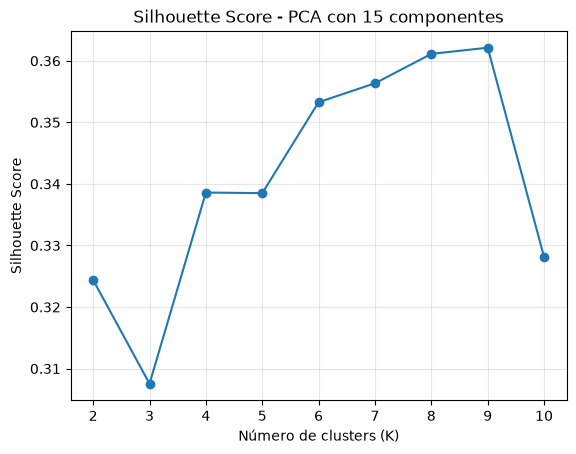

In [23]:
plt.plot(
    resultados_k_15["K"],
    resultados_k_15["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - PCA con 15 componentes")

plt.xticks(resultados_k_15["K"])
plt.grid(alpha=0.3)


#Guardar figura como 
ruta_figura = RAIZ_PROYECTO / "images" / "metrica1pca15.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")

plt.show()

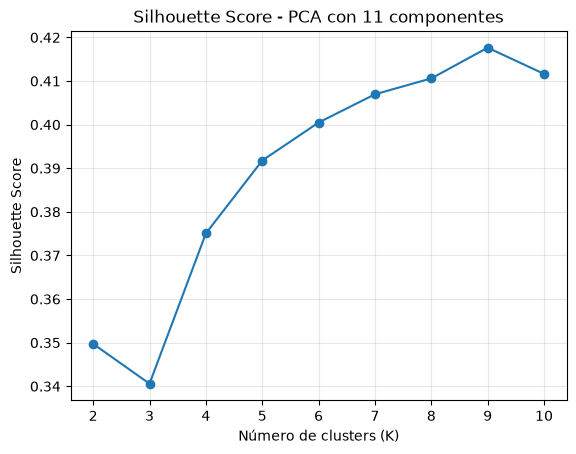

In [24]:
plt.plot(
    resultados_k_11["K"],
    resultados_k_11["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - PCA con 11 componentes")

plt.xticks(resultados_k_11["K"])
plt.grid(alpha=0.3)


#Guardar figura como 
ruta_figura = RAIZ_PROYECTO / "images" / "metrica1pca11.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")

plt.show()

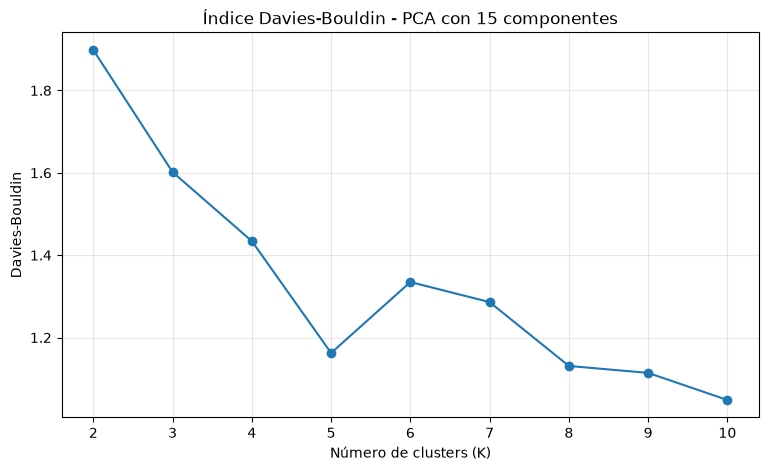

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_15["K"],
    resultados_k_15["Davies-Bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.title("Índice Davies-Bouldin - PCA con 15 componentes")

plt.xticks(resultados_k_15["K"])
plt.grid(alpha=0.3)

#Guardar figura como 
ruta_figura = RAIZ_PROYECTO / "images" / "metrica2pca15.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")


plt.show()

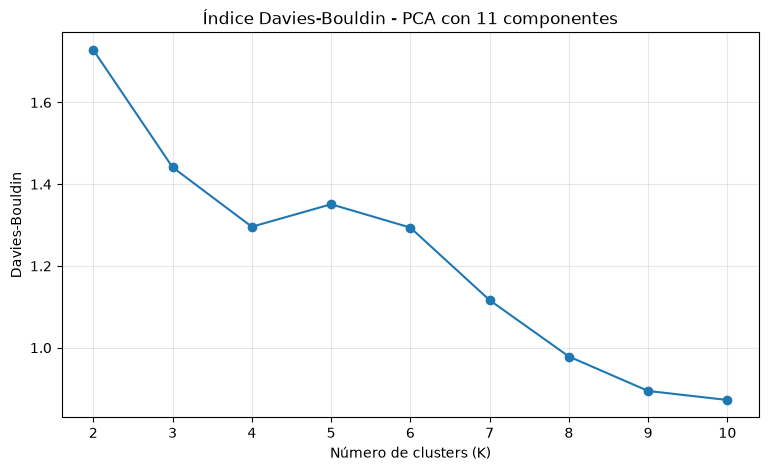

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_11["K"],
    resultados_k_11["Davies-Bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.title("Índice Davies-Bouldin - PCA con 11 componentes")

plt.xticks(resultados_k_11["K"])
plt.grid(alpha=0.3)

#Guardar figura como 
ruta_figura = RAIZ_PROYECTO / "images" / "metrica2pca11.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")


plt.show()

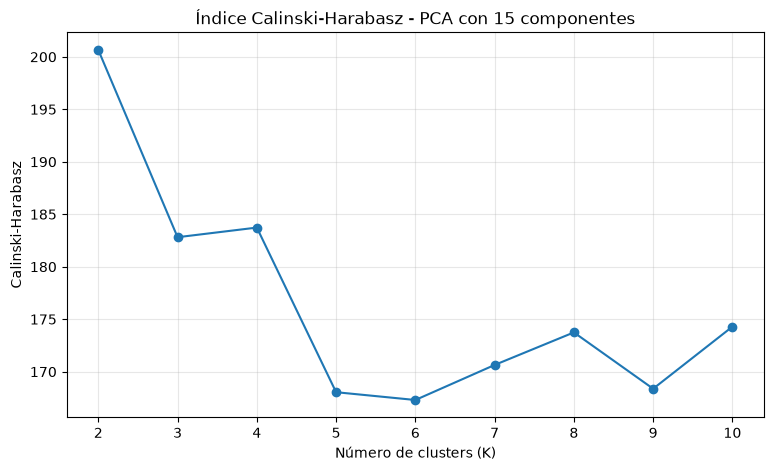

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_15["K"],
    resultados_k_15["Calinski-Harabasz"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.title("Índice Calinski-Harabasz - PCA con 15 componentes")

plt.xticks(resultados_k_15["K"])
plt.grid(alpha=0.3)

#Guardar figura como 
ruta_figura = RAIZ_PROYECTO / "images" / "metrica3pca15.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")

plt.show()

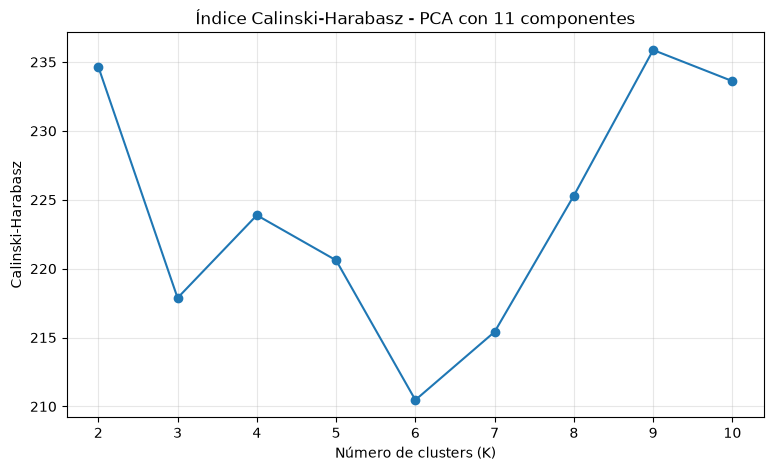

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultados_k_11["K"],
    resultados_k_11["Calinski-Harabasz"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.title("Índice Calinski-Harabasz - PCA con 11 componentes")

plt.xticks(resultados_k_11["K"])
plt.grid(alpha=0.3)

#Guardar figura como 
ruta_figura = RAIZ_PROYECTO / "images" / "metrica3pca11.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")

plt.show()

La comparación entre las representaciones de **PC15**, que conserva aproximadamente el 91% de la variabilidad acumulada, y PC11, que conserva aproximadamente el 80%, muestra que una mayor cantidad de varianza explicada no necesariamente se traduce en una mejor estructura de clustering. Para todos los valores de $K$ evaluados, la representación con PC11 obtiene un Silhouette Score superior al de PC15, alcanzando un máximo de 0.4176 en $K=9$, frente a 0.3621 en PC15. Esto indica una mayor cohesión interna y separación entre los clusters utilizando únicamente las primeras 11 componentes.

En cuanto al Davies-Bouldin Index, PC11 presenta valores inferiores a PC15 en la mayoría de los valores de $K$, siendo especialmente favorable para $K=8$, $K=9$ y $K=10$, donde alcanza valores de 0.9785, 0.8943 y 0.8721, respectivamente. La única excepción corresponde a $K=5$, donde PC15 presenta un valor ligeramente menor (1.1625 frente a 1.3509). Debido a que valores menores de Davies-Bouldin son preferibles, los resultados en general favorecen a PC11.

El Calinski-Harabasz Index también presenta valores superiores para PC11 en todos los valores de $K$ evaluados. Por ejemplo, para $K=9$, PC11 alcanza 235.8706, mientras que PC15 obtiene 168.3753. Esto indica que, bajo este criterio, la representación con 11 componentes presenta una relación más favorable entre la dispersión entre grupos y la dispersión interna.

En conjunto, los resultados muestran que PC11 proporciona una estructura de clustering más favorable que PC15 a pesar de conservar un porcentaje menor de la variabilidad total. Esto sugiere que las cuatro componentes adicionales de PC15, aunque aportan aproximadamente un 10% adicional de variabilidad explicada, no necesariamente mejoran la capacidad de los datos para formar clusters; incluso pueden introducir información que no contribuye a una separación más clara de los grupos. Sin embargo, esta última interpretación debe considerarse como una hipótesis y no como una conclusión definitiva únicamente a partir de estas métricas.

Por tanto, PC11 se perfila como una representación más eficiente para el clustering, ya que logra mejores resultados de cohesión y separación utilizando menos componentes. 

No obstante, la selección definitiva entre PC11 y PC15 no se realizará únicamente con estas métricas, sino que se complementará con el tamaño y balance de los clusters, la estabilidad de las soluciones mediante ARI y la interpretabilidad financiera de los grupos.

### 6.4 Comparación de tamaño de clusters y balance

La distribución de las observaciones entre clusters permite comprobar si la solución seleccionada produce grupos razonablemente representados.

El tamaño de cada cluster debe interpretarse conjuntamente con la naturaleza de las entidades financieras. Un cluster pequeño no necesariamente representa un error: puede corresponder a entidades con características financieras particulares.

In [29]:
tamano_clusters_15 = cl.evaluar_tamano_clusters(X_15)

tamano_clusters_15

,K,Cluster,Observaciones,Porcentaje
0,2,0,889,73.653687
1,2,1,318,26.346313
2,3,0,895,74.150787
3,3,1,59,4.888152
4,3,2,253,20.961060
5,4,0,846,70.091135
6,4,1,251,20.795360
7,4,2,51,4.225352
8,4,3,59,4.888152
9,5,0,845,70.008285


In [30]:
tamano_clusters_11 = cl.evaluar_tamano_clusters(X_11)

tamano_clusters_11

,K,Cluster,Observaciones,Porcentaje
0,2,0,323,26.760563
1,2,1,884,73.239437
2,3,0,890,73.736537
3,3,1,61,5.053853
4,3,2,256,21.209611
5,4,0,839,69.511185
6,4,1,256,21.209611
7,4,2,61,5.053853
8,4,3,51,4.225352
9,5,0,95,7.870754


In [31]:
# Copiar las tablas originales
tamano_15 = tamano_clusters_15.copy()
tamano_11 = tamano_clusters_11.copy()

# Renombrar las columnas de PC15
tamano_15 = tamano_15.rename(columns={
    "K": "K_PC15",
    "Cluster": "Cluster_PC15",
    "Observaciones": "Observaciones_PC15",
    "Porcentaje": "Porcentaje_PC15"
})

# Renombrar las columnas de PC11
tamano_11 = tamano_11.rename(columns={
    "K": "K_PC11",
    "Cluster": "Cluster_PC11",
    "Observaciones": "Observaciones_PC11",
    "Porcentaje": "Porcentaje_PC11"
})

# Unir horizontalmente las dos tablas
tamanio_comparativo = pd.concat(
    [tamano_15.reset_index(drop=True),
     tamano_11.reset_index(drop=True)],
    axis=1
)

# Redondear porcentajes
tamanio_comparativo["Porcentaje_PC15"] = (
    tamanio_comparativo["Porcentaje_PC15"].round(2)
)

tamanio_comparativo["Porcentaje_PC11"] = (
    tamanio_comparativo["Porcentaje_PC11"].round(2)
)

tamanio_comparativo

,K_PC15,Cluster_PC15,Observaciones_PC15,Porcentaje_PC15,K_PC11,Cluster_PC11,Observaciones_PC11,Porcentaje_PC11
0,2,0,889,73.65,2,0,323,26.76
1,2,1,318,26.35,2,1,884,73.24
2,3,0,895,74.15,3,0,890,73.74
3,3,1,59,4.89,3,1,61,5.05
4,3,2,253,20.96,3,2,256,21.21
5,4,0,846,70.09,4,0,839,69.51
6,4,1,251,20.80,4,1,256,21.21
7,4,2,51,4.23,4,2,61,5.05
8,4,3,59,4.89,4,3,51,4.23
9,5,0,845,70.01,5,0,95,7.87


In [32]:
ruta_resultados = RAIZ_PROYECTO / "results" / "clustering_results.xlsx"

with pd.ExcelWriter(
    ruta_resultados,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    tamanio_comparativo.to_excel(
        writer,
        sheet_name="tamanio",
        index=False
    )

print(f"Hoja 'tamanio' guardada en: {ruta_resultados}")

Hoja 'tamanio' guardada en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\clustering_results.xlsx


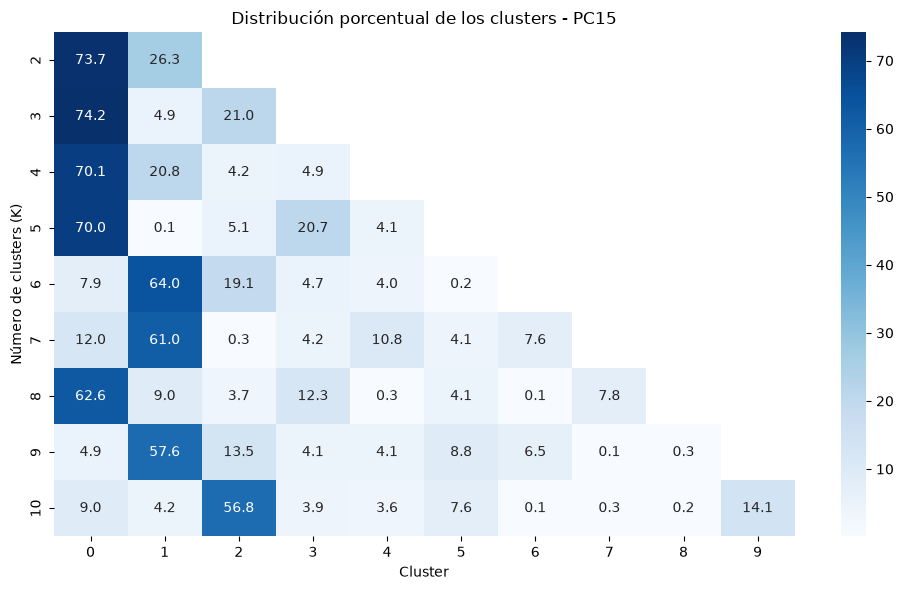

In [33]:
# ============================================================
# Tabla de proporciones para PC15
proporcion_15 = tamano_clusters_15.pivot(
    index="K",
    columns="Cluster",
    values="Porcentaje"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    proporcion_15,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Distribución porcentual de los clusters - PC15")
plt.xlabel("Cluster")
plt.ylabel("Número de clusters (K)")

plt.tight_layout()

#Guardar figura como 
ruta_figura = RAIZ_PROYECTO / "images" / "tamaniopca15.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

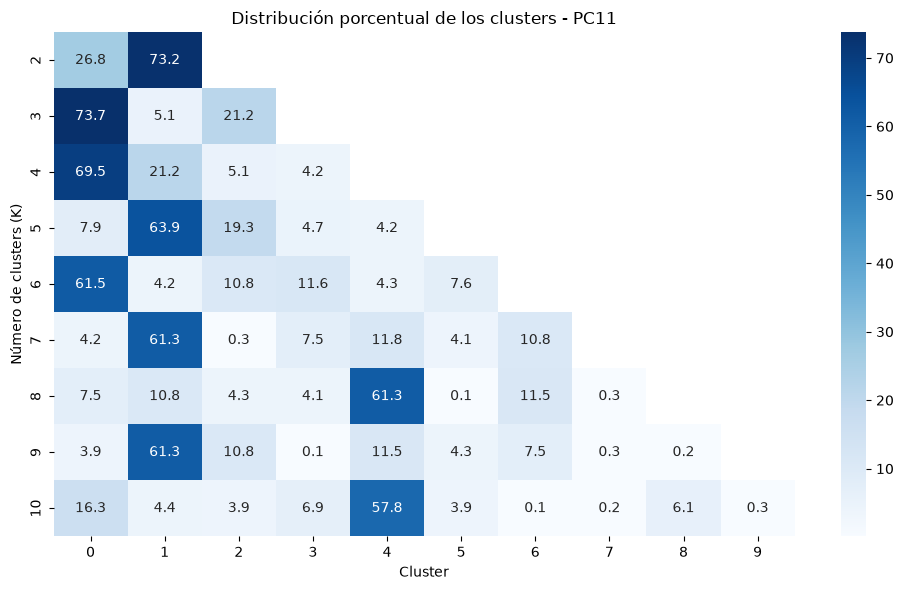

In [34]:
# ============================================================
# Tabla de proporciones para PC15
proporcion_11 = tamano_clusters_11.pivot(
    index="K",
    columns="Cluster",
    values="Porcentaje"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    proporcion_11,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Distribución porcentual de los clusters - PC11")
plt.xlabel("Cluster")
plt.ylabel("Número de clusters (K)")

plt.tight_layout()

#Guardar figura como 
ruta_figura = RAIZ_PROYECTO / "images" / "tamaniopca11.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

El análisis del tamaño y la proporción de los clusters permite evaluar qué tan equilibradas y representativas son las soluciones obtenidas para cada valor de $K$. En ambas representaciones, PC15 y PC11, se observa que para valores bajos de $K$ la población se concentra en pocos grupos de tamaño considerable, mientras que al aumentar el número de clusters la distribución se fragmenta progresivamente y aparecen grupos con proporciones muy pequeñas. 

Para $K=2$, ambas representaciones generan dos grupos ampliamente representativos, con proporciones de **Cluster 0:73,65% y Cluster 1:26,35% en PC15**, y **Cluster 0: 26,76% y Cluster 1: 73,24% en PC11**, la distribución es prácticamente equivalente. 

Para $K=3$ y $K=4$, ambas representaciones mantienen una estructura similar, con un cluster mayoritario cercano al **70%-74%**, un segundo grupo alrededor del **20%-21%** y grupos minoritarios de aproximadamente **4%-5%**. 

A partir de $K=5$, comienzan a observarse diferencias más importantes entre las representaciones y aparecen clusters extremadamente pequeños; por ejemplo, en PC15, $K=5$ genera un cluster de apenas **0,08%** y $K=6$ uno de **0,25%**, mientras que en PC11 se mantiene una distribución más repartida entre varios grupos. 

Para valores altos como $K=9$ y $K=10$, ambas representaciones presentan una mayor fragmentación, incluyendo clusters con proporciones inferiores al **1%**, lo que reduce su representatividad y puede dificultar su interpretación financiera. 

En consecuencia, el análisis del tamaño y proporción no favorece automáticamente valores altos de $K$, sino que permite identificar el grado de fragmentación de cada solución. 

En conjunto, $K=2$, $K=3$ y $K=4$ presentan una distribución más manejable y representativa, mientras que valores superiores incrementan progresivamente el riesgo de generar clusters demasiado pequeños. Por tanto, este criterio sugiere concentrar el análisis posterior en soluciones con un número moderado de clusters y contrastarlas con la estabilidad mediante ARI y la interpretabilidad financiera, antes de seleccionar el $K$ definitivo.

### 6.5 Comparación por estabilidad del clustering: Adjusted Rand Index (ARI)

In [35]:
semillas = [0, 1, 2, 3, 4, 5, 10, 20, 42, 100]

In [36]:
estabilidad_ari_15 = cl.evaluar_estabilidad_ari(
    X=X_15,
    semillas=semillas,
    k_min=2,
    k_max=10,
    n_init=10
)

estabilidad_ari_15.round(4)

,K,ARI_media,ARI_std,ARI_min,ARI_max
0,2,0.9988,0.0017,0.9965,1.0000
1,3,0.9942,0.0050,0.9895,1.0000
2,4,0.9939,0.0038,0.9873,1.0000
3,5,0.9141,0.0879,0.8123,1.0000
4,6,0.9338,0.0829,0.6903,1.0000
5,7,0.8987,0.0700,0.8117,1.0000
6,8,0.9035,0.0506,0.8072,1.0000
7,9,0.8009,0.1268,0.5124,0.9913
8,10,0.8797,0.0561,0.7398,0.9771


In [37]:
estabilidad_ari_11 = cl.evaluar_estabilidad_ari(
    X=X_11,
    semillas=semillas,
    k_min=2,
    k_max=10,
    n_init=10
)

estabilidad_ari_11.round(4)

,K,ARI_media,ARI_std,ARI_min,ARI_max
0,2,0.9988,0.0017,0.9965,1.0000
1,3,0.9915,0.0072,0.9794,1.0000
2,4,1.0000,0.0000,1.0000,1.0000
3,5,0.9606,0.0748,0.8092,1.0000
4,6,0.9106,0.0864,0.7684,1.0000
5,7,0.9185,0.0764,0.7748,1.0000
6,8,0.8800,0.0747,0.7746,1.0000
7,9,0.9376,0.0701,0.8062,1.0000
8,10,0.8835,0.0610,0.7923,0.9943


In [38]:
# Copiar las tablas para no modificar los resultados originales
ari_15 = estabilidad_ari_15.copy()
ari_11 = estabilidad_ari_11.copy()

# Renombrar columnas de PC15
ari_15 = ari_15.rename(columns={
    "K": "K_PC15",
    "ARI_media": "ARI_media_PC15",
    "ARI_std": "ARI_std_PC15",
    "ARI_min": "ARI_min_PC15",
    "ARI_max": "ARI_max_PC15"
})

# Renombrar columnas de PC11
ari_11 = ari_11.rename(columns={
    "K": "K_PC11",
    "ARI_media": "ARI_media_PC11",
    "ARI_std": "ARI_std_PC11",
    "ARI_min": "ARI_min_PC11",
    "ARI_max": "ARI_max_PC11"
})

# Unir ambas representaciones horizontalmente
estabilidad_ari_comparativa = pd.concat(
    [
        ari_15.reset_index(drop=True),
        ari_11.reset_index(drop=True)
    ],
    axis=1
)

# Redondear resultados
estabilidad_ari_comparativa = estabilidad_ari_comparativa.round(4)

estabilidad_ari_comparativa

,K_PC15,ARI_media_PC15,ARI_std_PC15,ARI_min_PC15,ARI_max_PC15,K_PC11,ARI_media_PC11,ARI_std_PC11,ARI_min_PC11,ARI_max_PC11
0,2,0.9988,0.0017,0.9965,1.0000,2,0.9988,0.0017,0.9965,1.0000
1,3,0.9942,0.0050,0.9895,1.0000,3,0.9915,0.0072,0.9794,1.0000
2,4,0.9939,0.0038,0.9873,1.0000,4,1.0000,0.0000,1.0000,1.0000
3,5,0.9141,0.0879,0.8123,1.0000,5,0.9606,0.0748,0.8092,1.0000
4,6,0.9338,0.0829,0.6903,1.0000,6,0.9106,0.0864,0.7684,1.0000
5,7,0.8987,0.0700,0.8117,1.0000,7,0.9185,0.0764,0.7748,1.0000
6,8,0.9035,0.0506,0.8072,1.0000,8,0.8800,0.0747,0.7746,1.0000
7,9,0.8009,0.1268,0.5124,0.9913,9,0.9376,0.0701,0.8062,1.0000
8,10,0.8797,0.0561,0.7398,0.9771,10,0.8835,0.0610,0.7923,0.9943


In [39]:
ruta_resultados = RAIZ_PROYECTO / "results" / "clustering_results.xlsx"

with pd.ExcelWriter(
    ruta_resultados,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    estabilidad_ari_comparativa.to_excel(
        writer,
        sheet_name="estabilidad_ARI",
        index=False
    )

print(f"Hoja 'estabilidad_ARI' guardada en: {ruta_resultados}")

Hoja 'estabilidad_ARI' guardada en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\clustering_results.xlsx


El análisis de estabilidad mediante el Adjusted Rand Index (ARI) muestra que las soluciones con K=2, K=3 y K=4 presentan una estabilidad muy elevada en
ambas representaciones de componentes principales.

Sin embargo, la representación basada en PC11 presenta una ventaja particular para K=4, alcanzando un ARI medio de 1.0000, una desviación estándar de 0.0000
y un ARI mínimo y máximo de 1.0000. Esto indica que las diez inicializaciones evaluadas produjeron exactamente la misma partición, evidenciando una
estabilidad perfecta de la solución.

A partir de K=5 se observa una mayor variabilidad de las particiones y, en general, una disminución de la estabilidad. Además, el análisis del tamaño de
los clusters muestra que valores elevados de K generan una mayor fragmentación y pueden producir grupos con muy pocas observaciones.

Por otra parte, PC11 presenta mejores resultados que PC15 en las métricas de Silhouette, Davies-Bouldin y Calinski-Harabasz para K=4, además de retener una
representación más parsimoniosa de la información.

## 7. Selección de K y dataset 



Para determinar el número adecuado de clusters se evaluaron valores de **K entre 2 y 10** utilizando las representaciones **PC15** y **PC11**. La selección se realizó considerando conjuntamente tres criterios: **calidad geométrica del clustering**, mediante Silhouette, Davies-Bouldin y Calinski-Harabasz; **tamaño y distribución de los clusters**; y **estabilidad de las particiones**, evaluada mediante el Adjusted Rand Index (ARI) utilizando diferentes semillas aleatorias.

Las métricas geométricas muestran que PC11 presenta, en general, una estructura de clustering más favorable que PC15. Para K=4, PC11 obtiene un Silhouette de 0.3751, un Davies-Bouldin de 1.2959 y un Calinski-Harabasz de 223.8791, frente a 0.3386, 1.4342 y 183.7309, respectivamente, para PC15.

El análisis del tamaño de los clusters muestra que K=2, K=3 y K=4 generan distribuciones más manejables, mientras que valores superiores incrementan la fragmentación y pueden producir grupos con muy pocas observaciones. En particular, para PC11 con K=4, los cuatro clusters representan aproximadamente el 69.51%, 21.21%, 5.05% y 4.23% de las observaciones, sin generar grupos extremadamente pequeños.

La estabilidad mediante ARI confirma esta tendencia. Las soluciones con K=2, K=3 y K=4 presentan una estabilidad muy elevada; sin embargo, PC11 con K=4 alcanza un ARI medio, mínimo y máximo de 1.0000 y una desviación estándar de 0.0000, indicando que las diferentes inicializaciones evaluadas produjeron exactamente la misma partición. A partir de K=5 se observa, en general, una mayor variabilidad y fragmentación de las soluciones.

Aunque PC15 conserva aproximadamente el 91% de la varianza acumulada frente al 80% de PC11, la mayor varianza explicada no implica necesariamente una mejor solución de clustering. En este caso, PC11 proporciona una representación más parsimoniosa y presenta mejores resultados en las métricas de calidad para K=4, además de una estabilidad perfecta.



Los resultados de estabilidad para **PC15** muestran que las soluciones con $K=2$, $K=3$ y $K=4$ presentan una estabilidad muy elevada, con medias de ARI superiores a **0.99**, desviaciones estándar inferiores a **0.01** y valores mínimos de ARI superiores a **0.98**. Esto indica que las asignaciones de las observaciones son prácticamente consistentes entre las diferentes inicializaciones de K-Means. A partir de $K=5$, la estabilidad disminuye y aumenta la variabilidad entre las soluciones, siendo especialmente evidente en $K=9$, donde la media del ARI es **0.8009**, la desviación estándar alcanza **0.1268** y el ARI mínimo disminuye hasta **0.5124**. Por tanto, aunque las métricas internas de agrupamiento favorecieron valores altos de $K$, particularmente $K=9$ y $K=10$, el análisis de estabilidad proporciona evidencia a favor de soluciones con un número menor de clusters. En consecuencia, **K=2, K=3 y K=4 se consideran candidatos particularmente estables**, y deberán ser contrastados con el análisis del tamaño y balance de los clusters y, posteriormente, con la **interpretabilidad financiera** para determinar la solución final.

**Conclusión**

Considerando conjuntamente la **estabilidad de las particiones, el tamaño y representatividad de los clusters, la estructura geométrica y la parsimonia de la representación**, se selecciona **PC11 con K=4** como la solución final de clustering. Esta configuración ofrece un equilibrio adecuado entre estabilidad, capacidad de segmentación e interpretabilidad, por lo que será utilizada para la **caracterización posterior de los cuatro perfiles financieros identificados**.

## 8. Definición de perfiles con K=4 y PC11

Una vez seleccionada la representación basada en **11 componentes principales
(PC11)** y **K=4** como solución final, se asigna cada observación a uno de los
cuatro clusters mediante K-Means.

La asignación de clusters se realiza utilizando los componentes principales,
mientras que la **caracterización e interpretación financiera** se realiza
posteriormente utilizando los indicadores originales de la base de datos.

Este procedimiento permite separar dos etapas del análisis: los componentes
principales se utilizan para identificar los grupos de observaciones con
características similares, y los indicadores financieros originales permiten
interpretar las características económicas y financieras de cada grupo.

In [40]:
# Modelo final seleccionado: PC11 con K=4
kmeans_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Asignación de clusters
clusters_k4 = kmeans_k4.fit_predict(X_11)


# Incorporar la etiqueta del cluster a la base utilizada en el PCA
base_cluster_k4 = base_pca_11.copy()
base_cluster_k4["CLUSTER"] = clusters_k4

In [41]:
resumen_clusters = (
    base_cluster_k4["CLUSTER"]
    .value_counts()
    .sort_index()
    .rename("Observaciones")
    .to_frame()
)

resumen_clusters["Porcentaje"] = (
    resumen_clusters["Observaciones"]
    / len(base_cluster_k4)
    * 100
)

resumen_clusters

,Observaciones,Porcentaje
CLUSTER,,
0,839,69.511185
1,256,21.209611
2,61,5.053853
3,51,4.225352


El cluster 0 se lleva el 69,5% de las observaciones, siendo el cluster más grande, el cluster 1 contiene el 21,2% , le sigue el cluster 2 con el 5% y finalmente, el cluster 3 con 4,2%.

In [42]:
# Verificación: todas las observaciones deben tener un cluster asignado
base_cluster_k4["CLUSTER"].isna().sum()

np.int64(0)

In [43]:
base_cluster_k4

,ENTIDAD,AÑO,MES,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,CLUSTER
0,BP GUAYAQUIL,2022,Mayo,1.670342,0.502378,-0.042178,-0.416485,-0.400375,0.588000,0.064495,0.431002,0.177570,0.118129,-0.145020,0
1,BP PACIFICO,2022,Mayo,-0.115302,1.558394,0.224624,-0.709578,-0.588994,-0.313127,-1.171238,-0.770440,-0.493185,0.053260,0.456137,0
2,BP PICHINCHA,2022,Mayo,1.156170,0.988809,0.026462,-0.498895,-0.637781,1.734360,0.260856,0.023198,0.391105,-0.580334,-0.289392,0
3,BP PRODUBANCO,2022,Mayo,1.640119,0.536627,-0.123829,-0.298324,-0.054004,0.720307,0.467011,0.166455,0.156224,0.035843,-0.111232,0
4,BP AUSTRO,2022,Mayo,0.613680,1.255829,-0.521440,-0.107046,-0.267844,0.702825,-0.521407,0.085341,0.032046,0.346037,0.002290,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,BP CAPITAL,2026,Julio,1.036045,0.227411,-1.546591,0.695227,-0.837032,0.742020,0.968712,0.628746,0.187723,1.542562,-0.235664,0
1203,BP DELBANK,2026,Julio,-2.120450,-2.090063,2.385544,-0.537215,-0.373405,-1.266998,-1.235508,-0.127112,-0.825867,1.035622,0.754134,1
1204,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,2026,Julio,1.424937,-1.549639,-4.348719,1.904478,-0.426288,0.884874,2.074304,0.699339,0.063287,1.067194,-0.093669,0
1205,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",2026,Julio,-0.057928,1.335613,0.959604,-0.750871,0.050477,0.373853,-0.449851,0.709412,0.316063,-0.246174,-0.184032,0


In [44]:
# Diccionario para convertir los meses en español a número
meses = {
    "ENERO": 1,
    "FEBRERO": 2,
    "MARZO": 3,
    "ABRIL": 4,
    "MAYO": 5,
    "JUNIO": 6,
    "JULIO": 7,
    "AGOSTO": 8,
    "SEPTIEMBRE": 9,
    "OCTUBRE": 10,
    "NOVIEMBRE": 11,
    "DICIEMBRE": 12
}

# Convertir MES a mayúsculas y luego a número
base_cluster_k4["MES_NUM"] = (
    base_cluster_k4["MES"]
    .str.upper()
    .str.strip()
    .map(meses)
)

# Construir la fecha usando año y mes
base_cluster_k4["FECHA"] = pd.to_datetime(
    dict(
        year=base_cluster_k4["AÑO"],
        month=base_cluster_k4["MES_NUM"],
        day=1
    )
)

### 8.1 Caracterización de los clusters mediante indicadores financieros originales 

Los clusters fueron obtenidos utilizando las componentes principales de la
representación PC11. Sin embargo, para facilitar su interpretación financiera,
se recuperan los indicadores originales utilizados en el análisis previo.

Para ello, se vincula la asignación de cluster con la base original mediante
las variables identificadoras de cada observación. Posteriormente, se
estandarizan los indicadores financieros utilizando la distribución de toda la
muestra y se calcula su valor promedio dentro de cada cluster.

De esta manera, los valores positivos indican que el cluster presenta un
indicador superior al promedio de la muestra, mientras que los valores
negativos indican un valor inferior al promedio. La magnitud del valor
estandarizado permite identificar qué indicadores diferencian con mayor
intensidad a cada perfil.

In [45]:
### Se carga la base limpia previa al PCA con todos los indicadores
ruta_base_original = (
    RAIZ_PROYECTO / "data_processed" / "base_pca2.xlsx"
)

base_final = pd.read_excel(ruta_base_original)

In [46]:
base_final

,MES,AÑO,ENTIDAD,SUFICIENCIA PATRIMONIAL,INDICE DE CAPITALIZACION NETO: FK / FI,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,MOROSIDAD DE LA CARTERA TOTAL,COBERTURA DE LA CARTERA REFINANCIADA,COBERTURA DE LA CARTERA REESTRUCTURADA,...,FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO,CARTERA REFINANCIADA / CARTERA BRUTA,CARTERA REESTRUCTURADA / CARTERA BRUTA,VAR_FONDOS DISPONIBLES,VAR_INVERSIONES,VAR_CARTERA DE CRÉDITOS,VAR_TOTAL ACTIVO,VAR_Depósitos a la vista,VAR_Depósitos a plazo,VAR_TOTAL PATRIMONIO
0,Mayo,2022,BP GUAYAQUIL,410.634510,8.120787,86.653465,120.426351,1.324103,81.951397,370.180856,...,19.562887,1.710131,0.527229,-15.357506,-3.105869,21.963595,10.850009,14.419397,16.334925,8.087612
1,Mayo,2022,BP PACIFICO,276.006994,9.549144,78.284447,111.274525,3.081702,178.560615,227.330926,...,31.433210,9.543764,4.166759,-16.102362,15.214273,-0.671445,-0.215742,-3.749551,7.616585,2.003489
2,Mayo,2022,BP PICHINCHA,-1288.206946,8.728095,91.272390,142.387866,2.408577,146.778509,134.752458,...,16.140524,2.169764,4.722154,-34.596167,0.889363,34.189556,10.684144,9.095698,17.660489,4.376836
3,Mayo,2022,BP PRODUBANCO,345.788698,7.046035,88.058836,146.171009,1.442211,89.147317,198.464154,...,25.246897,0.607335,2.484534,-4.501507,-3.521776,24.150188,13.806515,9.297570,11.956282,7.797315
4,Mayo,2022,BP AUSTRO,129.543127,7.715342,83.966638,104.258095,3.898154,60.387736,136.395986,...,24.560385,7.008823,2.783564,-15.937829,6.911905,21.409839,11.400689,7.823076,4.820617,12.813348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,Julio,2026,BP CAPITAL,74.360823,8.877858,79.688225,97.499072,4.329603,42.553501,183.484928,...,24.140849,1.431514,0.247529,-1.764260,54.532954,43.405379,32.243631,4.628479,44.564605,4.072887
1203,Julio,2026,BP DELBANK,743.520441,28.876492,84.202134,176.981056,3.113181,77.719435,117.680006,...,59.111194,6.891239,0.384947,9.622450,-37.925514,-11.897364,-10.244491,-12.542475,-22.706797,5.183978
1204,Julio,2026,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,78.836924,5.519091,87.180904,96.598989,2.152263,41.948642,193.089938,...,33.103705,2.883851,0.751003,139.889649,50.905153,78.103791,71.293760,27.512148,109.688042,-5.648516
1205,Julio,2026,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",299.062134,10.365757,89.475107,106.919132,9.916992,94.215098,134.193628,...,17.720955,4.113364,0.662222,-58.597055,24.865624,3.694559,-5.187257,-13.838419,8.657541,6.703112


In [47]:
# Se traslada la etiqueta obtenida mediante PCA+ K-means a la
# base de indicadores originales

columnas_id = ["ENTIDAD", "AÑO", "MES"]

base_caracterizacion = base_final.merge(
    base_cluster_k4[columnas_id + ["CLUSTER"]],
    on=columnas_id,
    how="inner"
)

In [48]:
variables_identificacion = [
    "ENTIDAD",
    "MES",
    "AÑO",
    "MES_NUM",
    "FECHA"
]

indicadores_financieros = [
    col for col in base_final.columns
    if col not in variables_identificacion
]

indicadores_financieros

['SUFICIENCIA PATRIMONIAL',
 'INDICE DE CAPITALIZACION NETO: FK / FI',
 'ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS',
 'ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO',
 'MOROSIDAD DE LA CARTERA TOTAL',
 'COBERTURA DE LA CARTERA REFINANCIADA',
 'COBERTURA DE LA CARTERA REESTRUCTURADA',
 'COBERTURA DE LA CARTERA PROBLEMÁTICA',
 'GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)',
 'GASTOS DE OPERACION  / MARGEN FINANCIERO',
 'GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)',
 'RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO',
 'RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO',
 'CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)',
 'FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO',
 'CARTERA REFINANCIADA / CARTERA BRUTA',
 'CARTERA REESTRUCTURADA / CARTERA BRUTA',
 'VAR_FONDOS DISPONIBLES',
 'VAR_INVERSIONES',
 'VAR_CARTERA DE CRÉDITOS',
 'VAR_TOTAL ACTIVO',
 'VAR_Depósitos a la vista',
 'VAR_Depósitos a plazo',
 'VAR_TOTAL PATRIMONIO']



Una vez asignadas las observaciones a los cuatro clusters, se calculan los valores promedio de los indicadores financieros originales para cada grupo.

Estos promedios permiten identificar las diferencias existentes entre los perfiles financieros antes de realizar su estandarización.

In [49]:
# Promedio de cada indicador financiero dentro de cada cluster
promedios_clusters = (
    base_caracterizacion
    .groupby("CLUSTER")[indicadores_financieros]
    .mean()
)

promedios_clusters.round(2)

,SUFICIENCIA PATRIMONIAL,INDICE DE CAPITALIZACION NETO: FK / FI,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,MOROSIDAD DE LA CARTERA TOTAL,COBERTURA DE LA CARTERA REFINANCIADA,COBERTURA DE LA CARTERA REESTRUCTURADA,COBERTURA DE LA CARTERA PROBLEMÁTICA,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3),GASTOS DE OPERACION / MARGEN FINANCIERO,...,FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO,CARTERA REFINANCIADA / CARTERA BRUTA,CARTERA REESTRUCTURADA / CARTERA BRUTA,VAR_FONDOS DISPONIBLES,VAR_INVERSIONES,VAR_CARTERA DE CRÉDITOS,VAR_TOTAL ACTIVO,VAR_Depósitos a la vista,VAR_Depósitos a plazo,VAR_TOTAL PATRIMONIO
CLUSTER,,,,,,,,,,,,,,,,,,,,,
0,107.45,9.26,86.70,113.60,3.44,119.15,247.80,5.685400e+02,4.04,109.58,...,27.45,3.16,1.78,8.89,22.05,12.14,12.00,11.13,18.46,8.48
1,746.29,19.94,89.78,142.69,6.11,87.29,173.81,1.370600e+02,9.19,72.92,...,36.27,4.71,1.96,25.55,15.60,8.57,7.73,51.08,15.77,2.50
2,98.82,8.54,81.35,97.09,20.11,55.79,115.03,6.989000e+01,9.75,404.09,...,36.39,9.68,6.01,4.12,73.02,-17.17,-7.81,3.61,2.83,-14.63
3,33628.72,11.13,85.81,738.03,0.00,0.00,0.00,1.236474e+09,3.71,71.25,...,31.51,0.00,0.21,-7.95,16.96,15.58,5.77,6.26,59874.35,5.89



Para facilitar la comparación entre indicadores que poseen diferentes escalas y unidades, se utiliza una estandarización basada en la distribución completa
de la muestra.

Para cada indicador se calcula su media y desviación estándar considerando todas las observaciones, independientemente del cluster al que pertenezcan.

In [50]:
# Media de cada indicador en toda la muestra
media_muestra = (
    base_caracterizacion[indicadores_financieros]
    .mean()
)

# Desviación estándar de cada indicador en toda la muestra
std_muestra = (
    base_caracterizacion[indicadores_financieros]
    .std()
)

media_muestra.round(2)

SUFICIENCIA PATRIMONIAL                                           1658.90
INDICE DE CAPITALIZACION NETO: FK / FI                              11.57
ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS                                 87.04
ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO                            145.32
MOROSIDAD DE LA CARTERA TOTAL                                        4.71
COBERTURA DE LA CARTERA REFINANCIADA                               104.16
COBERTURA DE LA CARTERA REESTRUCTURADA                             214.92
COBERTURA DE LA CARTERA PROBLEMÁTICA                          52245801.41
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)            5.40
GASTOS DE OPERACION  / MARGEN FINANCIERO                           115.07
GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)                   2.36
RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO                       2.79
RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO                           0.31
CARTERA BRUTA / (DEPOSITOS A LA VISTA 

Para cada indicador y cluster se calcula un valor estandarizado mediante:

$$
Z_{jk} =
\frac{\bar{X}_{jk} - \bar{X}_{j}}{s_j}
$$

donde:

- $\bar{X}_{jk}$ corresponde al promedio del indicador $j$ en el cluster $k$.
- $\bar{X}_{j}$ corresponde al promedio del indicador $j$ en toda la muestra.
- $s_j$ corresponde a la desviación estándar del indicador $j$ en toda la muestra.

Por tanto, el valor obtenido indica cuántas desviaciones estándar se encuentra
el promedio de cada cluster por encima o por debajo del promedio general.

Los valores positivos indican un comportamiento superior al promedio de la
muestra, mientras que los valores negativos indican un comportamiento inferior.

In [51]:
# Perfil estandarizado de cada cluster respecto al promedio de toda la muestra
perfil_estandarizado = (
    promedios_clusters - media_muestra
) / std_muestra

perfil_estandarizado.round(2)

,SUFICIENCIA PATRIMONIAL,INDICE DE CAPITALIZACION NETO: FK / FI,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,MOROSIDAD DE LA CARTERA TOTAL,COBERTURA DE LA CARTERA REFINANCIADA,COBERTURA DE LA CARTERA REESTRUCTURADA,COBERTURA DE LA CARTERA PROBLEMÁTICA,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3),GASTOS DE OPERACION / MARGEN FINANCIERO,...,FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO,CARTERA REFINANCIADA / CARTERA BRUTA,CARTERA REESTRUCTURADA / CARTERA BRUTA,VAR_FONDOS DISPONIBLES,VAR_INVERSIONES,VAR_CARTERA DE CRÉDITOS,VAR_TOTAL ACTIVO,VAR_Depósitos a la vista,VAR_Depósitos a plazo,VAR_TOTAL PATRIMONIO
CLUSTER,,,,,,,,,,,,,,,,,,,,,
0,-0.03,-0.41,-0.05,-0.20,-0.27,0.12,0.04,-0.20,-0.50,-0.01,...,-0.22,-0.15,-0.09,-0.06,-0.02,0.11,0.17,-0.12,-0.06,0.19
1,-0.02,1.48,0.40,-0.02,0.30,-0.13,-0.04,-0.20,1.39,-0.08,...,0.55,0.29,-0.00,0.31,-0.12,-0.08,-0.16,0.49,-0.06,-0.26
2,-0.03,-0.53,-0.84,-0.31,3.28,-0.37,-0.11,-0.20,1.60,0.58,...,0.56,1.70,1.97,-0.16,0.83,-1.42,-1.35,-0.23,-0.06,-1.54
3,0.63,-0.08,-0.18,3.83,-1.00,-0.81,-0.23,4.51,-0.62,-0.09,...,0.14,-1.05,-0.86,-0.43,-0.10,0.29,-0.31,-0.19,1.31,-0.00


El siguiente mapa de calor permite visualizar cómo se diferencia cada cluster
respecto al comportamiento promedio de la muestra.

Los valores positivos representan indicadores superiores al promedio general,
mientras que los valores negativos representan indicadores inferiores. La
intensidad del valor estandarizado permite identificar los indicadores que
presentan las mayores diferencias entre los perfiles financieros.

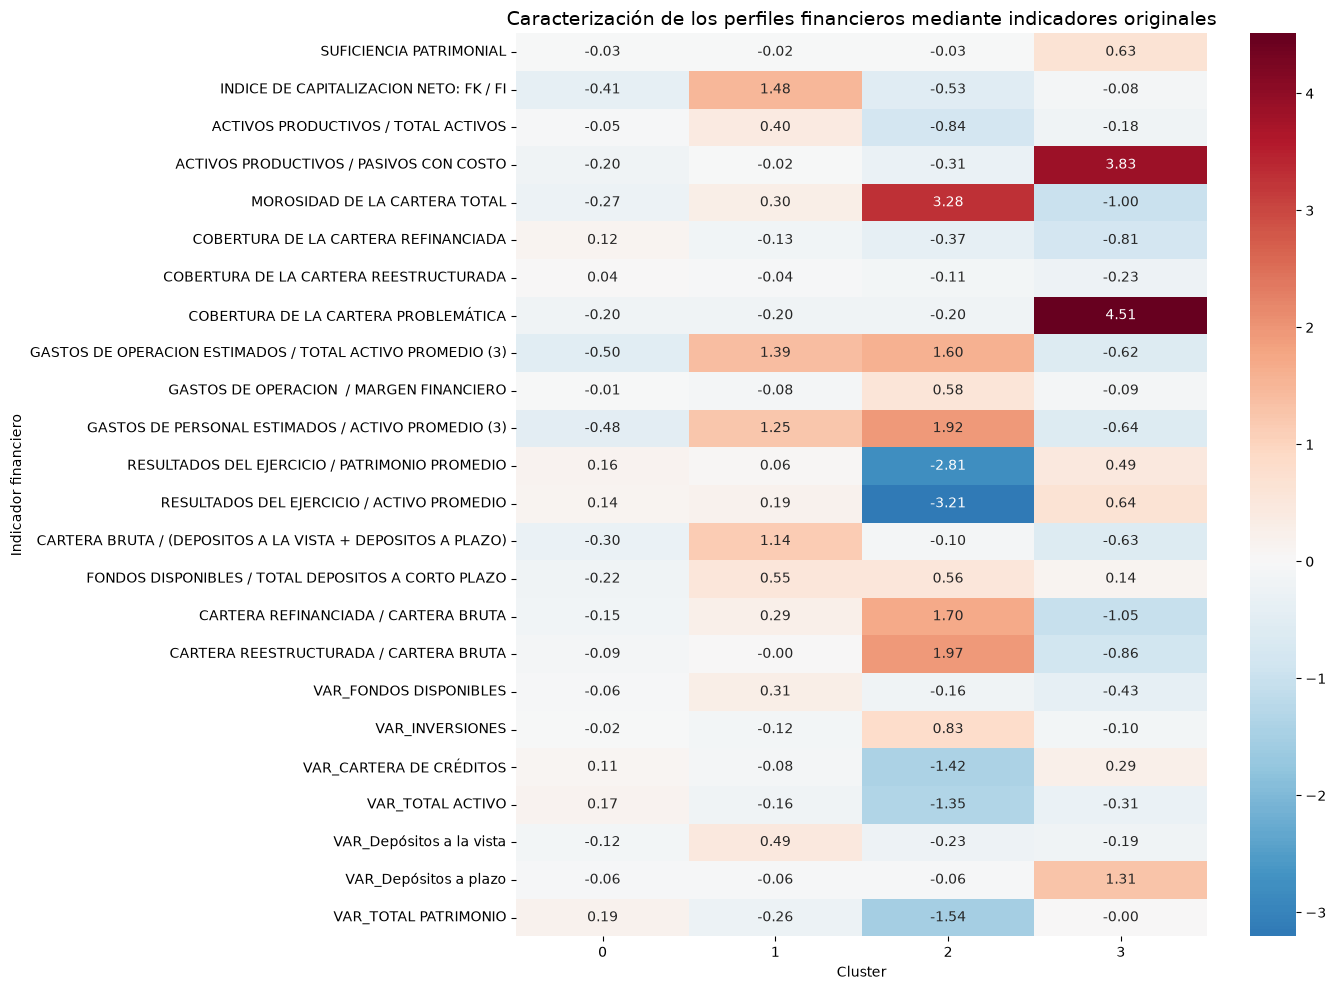

Gráfico guardado en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\cluster_caracterizacion.png


In [52]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    perfil_estandarizado.T,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdBu_r"
)

plt.title(
    "Caracterización de los perfiles financieros mediante indicadores originales",
    fontsize=14
)

plt.xlabel("Cluster")
plt.ylabel("Indicador financiero")

plt.tight_layout()


# Guardar como resultado del PCA
ruta_figura = RAIZ_PROYECTO / "results" / "cluster_caracterizacion.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico guardado en: {ruta_figura.resolve()}")

Los valores presentados en el Heatmap corresponden a puntuaciones respecto al promedio de toda la muestra. Por tanto, un valor positivo indica
que el indicador se encuentra por encima del promedio general, mientras que un valor negativo indica que se encuentra por debajo. La magnitud del valor
absoluto permite identificar la intensidad de la diferencia respecto al comportamiento promedio de la muestra.

Para la interpretación de los perfiles se consideran principalmente los indicadores  ordenados de mayor a menor
según su puntuación estandarizada.

**Cluster 0**

Los indicadores del Cluster 0, ordenados de mayor a menor respecto al promedio de la muestra, son:

1. Variación total del patrimonio: +0.19 desviaciones estándar.
2. Variación total de activos: +0.17 desviaciones estándar.
3. Resultados del ejercicio / patrimonio: +0.16 desviaciones estándar.
4. Resultados del ejercicio / activo: +0.14 desviaciones estándar.
5. Cobertura de la cartera refinanciada: +0.12 desviaciones estándar.
6. Variación de cartera de créditos: +0.11 desviaciones estándar.
7. Cobertura de la cartera reestructurada: +0.04 desviaciones estándar.
8. Suficiencia patrimonial: -0.03 desviaciones estándar.
9. Variación de inversiones: -0.02 desviaciones estándar.
10. Gastos de operación / margen financiero: -0.01 desviaciones estándar.
11. Activos productivos / total activos: -0.05 desviaciones estándar.
12. Variación de fondos disponibles: -0.06 desviaciones estándar.
13. Variación de depósitos a plazo: -0.06 desviaciones estándar.
14. Cartera reestructurada / cartera bruta: -0.09 desviaciones estándar.
15. Variación de depósitos a la vista: -0.12 desviaciones estándar.
16. Cartera refinanciada / cartera bruta: -0.15 desviaciones estándar.
17. Activos productivos / pasivos con costo: -0.20 desviaciones estándar.
18. Cobertura de la cartera problemática: -0.20 desviaciones estándar.
19. Fondos disponibles / depósitos a corto plazo: -0.22 desviaciones estándar.
20. Morosidad de la cartera total: -0.27 desviaciones estándar.
21. Cartera bruta / depósitos: -0.30 desviaciones estándar.
22. Índice de capitalización neto: -0.41 desviaciones estándar.
23. Gastos de personal estimados / activo: -0.48 desviaciones estándar.
24. Gastos de operación estimados / total activo: -0.50 desviaciones estándar.

**Perfil de estabilidad, crecimiento moderado y eficiencia relativa:** corresponde a entidades que presentan un crecimiento ligeramente superior al promedio en activos y patrimonio, acompañado de niveles de rentabilidad sobre activos y patrimonio también superiores al promedio. Asimismo, presentan menores gastos de operación y de personal respecto al activo, junto con una morosidad inferior al promedio. Los indicadores de cobertura de cartera se mantienen próximos al promedio, por lo que no se evidencia una diferencia marcada en esta dimensión. En conjunto, el cluster representa entidades con crecimiento moderado, rentabilidad ligeramente superior al promedio, menores gastos relativos y menor morosidad, manteniendo indicadores de cobertura cercanos al comportamiento general de la muestra.


**Cluster 1**

Los indicadores del Cluster 1, ordenados de mayor a menor son:

1. Índice de capitalización neto: +1.48 desviaciones estándar.
2. Gastos de operación estimados / total activo: +1.39 desviaciones estándar.
3. Gastos de personal estimados / activo: +1.25 desviaciones estándar.
4. Cartera bruta / depósitos: +1.14 desviaciones estándar.
5. Fondos disponibles / depósitos a corto plazo: +0.55 desviaciones estándar.
6. Variación de depósitos a la vista: +0.49 desviaciones estándar.
7. Activos productivos / total activos: +0.40 desviaciones estándar.
8. Variación de fondos disponibles: +0.31 desviaciones estándar.
9. Morosidad de la cartera total: +0.30 desviaciones estándar.
10. Cartera refinanciada / cartera bruta: +0.29 desviaciones estándar.
11. Resultados del ejercicio / activo: +0.19 desviaciones estándar.
12. Resultados del ejercicio / patrimonio: +0.06 desviaciones estándar.
13. Cartera reestructurada / cartera bruta: aproximadamente 0.00 desviaciones estándar.
14. Suficiencia patrimonial: -0.02 desviaciones estándar.
15. Activos productivos / pasivos con costo: -0.02 desviaciones estándar.
16. Cobertura de la cartera reestructurada: -0.04 desviaciones estándar.
17. Variación de depósitos a plazo: -0.06 desviaciones estándar.
18. Gastos de operación / margen financiero: -0.08 desviaciones estándar.
19. Variación de cartera de créditos: -0.08 desviaciones estándar.
20. Variación de inversiones: -0.12 desviaciones estándar.
21. Cobertura de la cartera refinanciada: -0.13 desviaciones estándar.
22. Variación total de activos: -0.16 desviaciones estándar.
23. Cobertura de la cartera problemática: -0.20 desviaciones estándar.
24. Variación total del patrimonio: -0.26 desviaciones estándar.




**Perfil de alta capitalización, intermediación y mayores gastos relativos:** Corresponde a entidades que presentan un índice de capitalización neto significativamente superior al promedio, acompañado de una mayor relación entre cartera bruta y depósitos. Asimismo, presentan mayores niveles de fondos disponibles respecto a los depósitos a corto plazo y una mayor proporción de activos productivos respecto al total de activos. Sin embargo, registran mayores gastos de operación y de personal respecto al activo, lo que evidencia una mayor estructura de gastos relativos. La morosidad de la cartera total se encuentra ligeramente por encima del promedio, al igual que la participación de la cartera refinanciada respecto de la cartera bruta. Por otro lado, los indicadores de rentabilidad se mantienen próximos al promedio, mientras que la variación de activos y patrimonio se encuentra ligeramente por debajo. En cuanto a los indicadores de cobertura, estos se mantienen cercanos al promedio, sin diferencias marcadas. En conjunto, el cluster representa entidades con elevada capitalización, mayor intensidad de intermediación y disponibilidad de fondos, acompañadas de mayores gastos relativos y un nivel de morosidad ligeramente superior al comportamiento general de la muestra.



**Cluster 2**

Los indicadores del Cluster 2, ordenados de mayor a menor  son:

1. Morosidad de la cartera total: +3.28 desviaciones estándar.
2. Cartera reestructurada / cartera bruta: +1.97 desviaciones estándar.
3. Gastos de personal estimados / activo: +1.92 desviaciones estándar.
4. Cartera refinanciada / cartera bruta: +1.70 desviaciones estándar.
5. Gastos de operación estimados / total activo: +1.60 desviaciones estándar.
6. Variación de inversiones: +0.83 desviaciones estándar.
7. Gastos de operación / margen financiero: +0.58 desviaciones estándar.
8. Fondos disponibles / depósitos a corto plazo: +0.56 desviaciones estándar.
9. Suficiencia patrimonial: -0.03 desviaciones estándar.
10. Variación de depósitos a plazo: -0.06 desviaciones estándar.
11. Cartera bruta / depósitos: -0.10 desviaciones estándar.
12. Cobertura de la cartera reestructurada: -0.11 desviaciones estándar.
13. Variación de fondos disponibles: -0.16 desviaciones estándar.
14. Cobertura de la cartera problemática: -0.20 desviaciones estándar.
15. Variación de depósitos a la vista: -0.23 desviaciones estándar.
16. Activos productivos / pasivos con costo: -0.31 desviaciones estándar.
17. Cobertura de la cartera refinanciada: -0.37 desviaciones estándar.
18. Índice de capitalización neto: -0.53 desviaciones estándar.
19. Activos productivos / total activos: -0.84 desviaciones estándar.
20. Variación total de activos: -1.35 desviaciones estándar.
21. Variación de cartera de créditos: -1.42 desviaciones estándar.
22. Variación total de patrimonio: -1.54 desviaciones estándar.
23. Resultados del ejercicio / patrimonio: -2.81 desviaciones estándar.
24. Resultados del ejercicio / activo: -3.21 desviaciones estándar.

**Perfil de mayor deterioro crediticio, menor rentabilidad y contracción relativa**: Corresponde a entidades que presentan una morosidad de la cartera total significativamente superior al promedio, acompañada de mayores proporciones de cartera reestructurada y refinanciada respecto de la cartera bruta. Asimismo, presentan mayores gastos de personal y de operación respecto al activo, junto con una mayor proporción de gastos de operación respecto al margen financiero. En contraste, registran niveles de rentabilidad sobre activos y patrimonio considerablemente inferiores al promedio, así como menores niveles de crecimiento del activo, patrimonio y cartera de créditos. La proporción de activos productivos respecto al total de activos también se encuentra por debajo del promedio, mientras que el índice de capitalización neto presenta un nivel inferior al comportamiento general de la muestra. Los indicadores de cobertura de cartera se mantienen por debajo del promedio, aunque las diferencias son menos pronunciadas que las observadas en morosidad y rentabilidad. En conjunto, el cluster representa entidades con mayor deterioro de la calidad de la cartera, mayores gastos relativos y menor rentabilidad, acompañados de una reducción relativa en el crecimiento de activos, patrimonio y cartera de créditos.



**Cluster 3**

Los indicadores del Cluster 3, ordenados de mayor a menor desviaciones estándar respecto al promedio de la muestra, son:

1. Cobertura de la cartera problemática: +4.51 desviaciones estándar.
2. Activos productivos / pasivos con costo: +3.83 desviaciones estándar.
3. Variación de depósitos a plazo: +1.31 desviaciones estándar.
4. Resultados del ejercicio / activo: +0.64 desviaciones estándar.
5. Suficiencia patrimonial: +0.63 desviaciones estándar.
6. Resultados del ejercicio / patrimonio: +0.49 desviaciones estándar.
7. Variación de cartera de créditos: +0.29 desviaciones estándar.
8. Fondos disponibles / depósitos a corto plazo: +0.14 desviaciones estándar.
9. Variación total del patrimonio: aproximadamente 0.00 desviaciones estándar.
10. Índice de capitalización neto: -0.08 desviaciones estándar.
11. Gastos de operación / margen financiero: -0.09 desviaciones estándar.
12. Variación de inversiones: -0.10 desviaciones estándar.
13. Activos productivos / total activos: -0.18 desviaciones estándar.
14. Variación de depósitos a la vista: -0.19 desviaciones estándar.
15. Cobertura de la cartera reestructurada: -0.23 desviaciones estándar.
16. Variación total de activos: -0.31 desviaciones estándar.
17. Variación de fondos disponibles: -0.43 desviaciones estándar.
18. Gastos de operación estimados / total activo: -0.62 desviaciones estándar.
19. Cartera bruta / depósitos: -0.63 desviaciones estándar.
20. Gastos de personal estimados / activo: -0.64 desviaciones estándar.
21. Cobertura de la cartera refinanciada: -0.81 desviaciones estándar.
22. Cartera reestructurada / cartera bruta: -0.86 desviaciones estándar.
23. Morosidad de la cartera total: -1.00 desviaciones estándar.
24. Cartera refinanciada / cartera bruta: -1.05 desviaciones estándar.

**Perfil de solidez crediticia, cobertura y rentabilidad superior:** corresponde a entidades que presentan una cobertura de la cartera problemática significativamente superior al promedio, acompañada de una elevada relación de activos productivos respecto de los pasivos con costo. Asimismo, presentan niveles superiores al promedio en suficiencia patrimonial, rentabilidad sobre activos y patrimonio y variación de la cartera de créditos. En contraste, muestran una morosidad significativamente inferior al promedio, junto con menores proporciones de cartera refinanciada y reestructurada respecto de la cartera bruta. También presentan menores gastos de operación y de personal respecto al activo. La variación de activos y fondos disponibles se encuentra por debajo del promedio, mientras que la variación de depósitos a plazo es superior. En conjunto, el cluster representa entidades con mayor cobertura y calidad crediticia, adecuada solidez patrimonial, rentabilidad superior al promedio y menores niveles de morosidad y cartera deteriorada, acompañadas de una estructura de activos productivos favorable y menores gastos relativos.

In [53]:
tabla_perfiles = []

for cluster in perfil_estandarizado.index:

    perfil = perfil_estandarizado.loc[cluster]

    valores_altos = (
        perfil
        .sort_values(ascending=False)
        .head(5)
    )

    valores_bajos = (
        perfil
        .sort_values(ascending=True)
        .head(5)
    )

    for indicador, valor in valores_altos.items():

        tabla_perfiles.append({
            "Cluster": cluster,
            "Tipo": "Superior al promedio",
            "Indicador": indicador,
            "Valor": valor
        })

    for indicador, valor in valores_bajos.items():

        tabla_perfiles.append({
            "Cluster": cluster,
            "Tipo": "Inferior al promedio",
            "Indicador": indicador,
            "Valor": valor
        })

tabla_perfiles = pd.DataFrame(tabla_perfiles)

tabla_perfiles

,Cluster,Tipo,Indicador,Valor
0,0,Superior al promedio,VAR_TOTAL PATRIMONIO,0.190829
1,0,Superior al promedio,VAR_TOTAL ACTIVO,0.166023
2,0,Superior al promedio,RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO,0.155160
3,0,Superior al promedio,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,0.136045
4,0,Superior al promedio,COBERTURA DE LA CARTERA REFINANCIADA,0.116157
5,0,Inferior al promedio,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,-0.501705
6,0,Inferior al promedio,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,-0.483203
7,0,Inferior al promedio,INDICE DE CAPITALIZACION NETO: FK / FI,-0.407313
8,0,Inferior al promedio,CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSI...,-0.301774
9,0,Inferior al promedio,MOROSIDAD DE LA CARTERA TOTAL,-0.268719


In [54]:
ruta_resultados = RAIZ_PROYECTO / "results" / "clustering_results.xlsx"

with pd.ExcelWriter(
    ruta_resultados,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    tabla_perfiles.to_excel(
        writer,
        sheet_name="perfiles_cluster_indicador",
        index=False
    )

print(f"Hoja 'perfiles_cluster_indicador' guardada en: {ruta_resultados}")

Hoja 'perfiles_cluster_indicador' guardada en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\clustering_results.xlsx


In [55]:
perfiles_resumen = []

for cluster in perfil_estandarizado.index:

    perfil = perfil_estandarizado.loc[cluster]

    indicadores_altos = (
        perfil
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

    indicadores_bajos = (
        perfil
        .sort_values(ascending=True)
        .head(5)
        .index
        .tolist()
    )

    perfiles_resumen.append({
        "Cluster": cluster,
        "Indicadores superiores al promedio": "; ".join(indicadores_altos),
        "Indicadores inferiores al promedio": "; ".join(indicadores_bajos)
    })

tabla_perfiles_sup_inf = pd.DataFrame(perfiles_resumen)

tabla_perfiles_sup_inf

,Cluster,Indicadores superiores al promedio,Indicadores inferiores al promedio
0,0,VAR_TOTAL PATRIMONIO; VAR_TOTAL ACTIVO; RESULT...,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...
1,1,INDICE DE CAPITALIZACION NETO: FK / FI; GASTOS...,VAR_TOTAL PATRIMONIO; COBERTURA DE LA CARTERA ...
2,2,MOROSIDAD DE LA CARTERA TOTAL; CARTERA REESTRU...,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO; RE...
3,3,COBERTURA DE LA CARTERA PROBLEMÁTICA; ACTIVOS ...,CARTERA REFINANCIADA / CARTERA BRUTA; MOROSIDA...


In [56]:
ruta_resultados = RAIZ_PROYECTO / "results" / "clustering_results.xlsx"

with pd.ExcelWriter(
    ruta_resultados,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    tabla_perfiles_sup_inf.to_excel(
        writer,
        sheet_name="perfiles_sup_inf",
        index=False
    )

print(f"Hoja 'perfiles_sup_inf' guardada en: {ruta_resultados}")

Hoja 'perfiles_sup_inf' guardada en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\clustering_results.xlsx


### 8.2 Perfiles de las entidades a través del tiempo

A continuación, se analiza la distribución
temporal entre las entidades. Esto permite observar si las instituciones
mantienen un perfil relativamente estable a lo largo del período de estudio o
si presentan cambios de cluster en el tiempo.

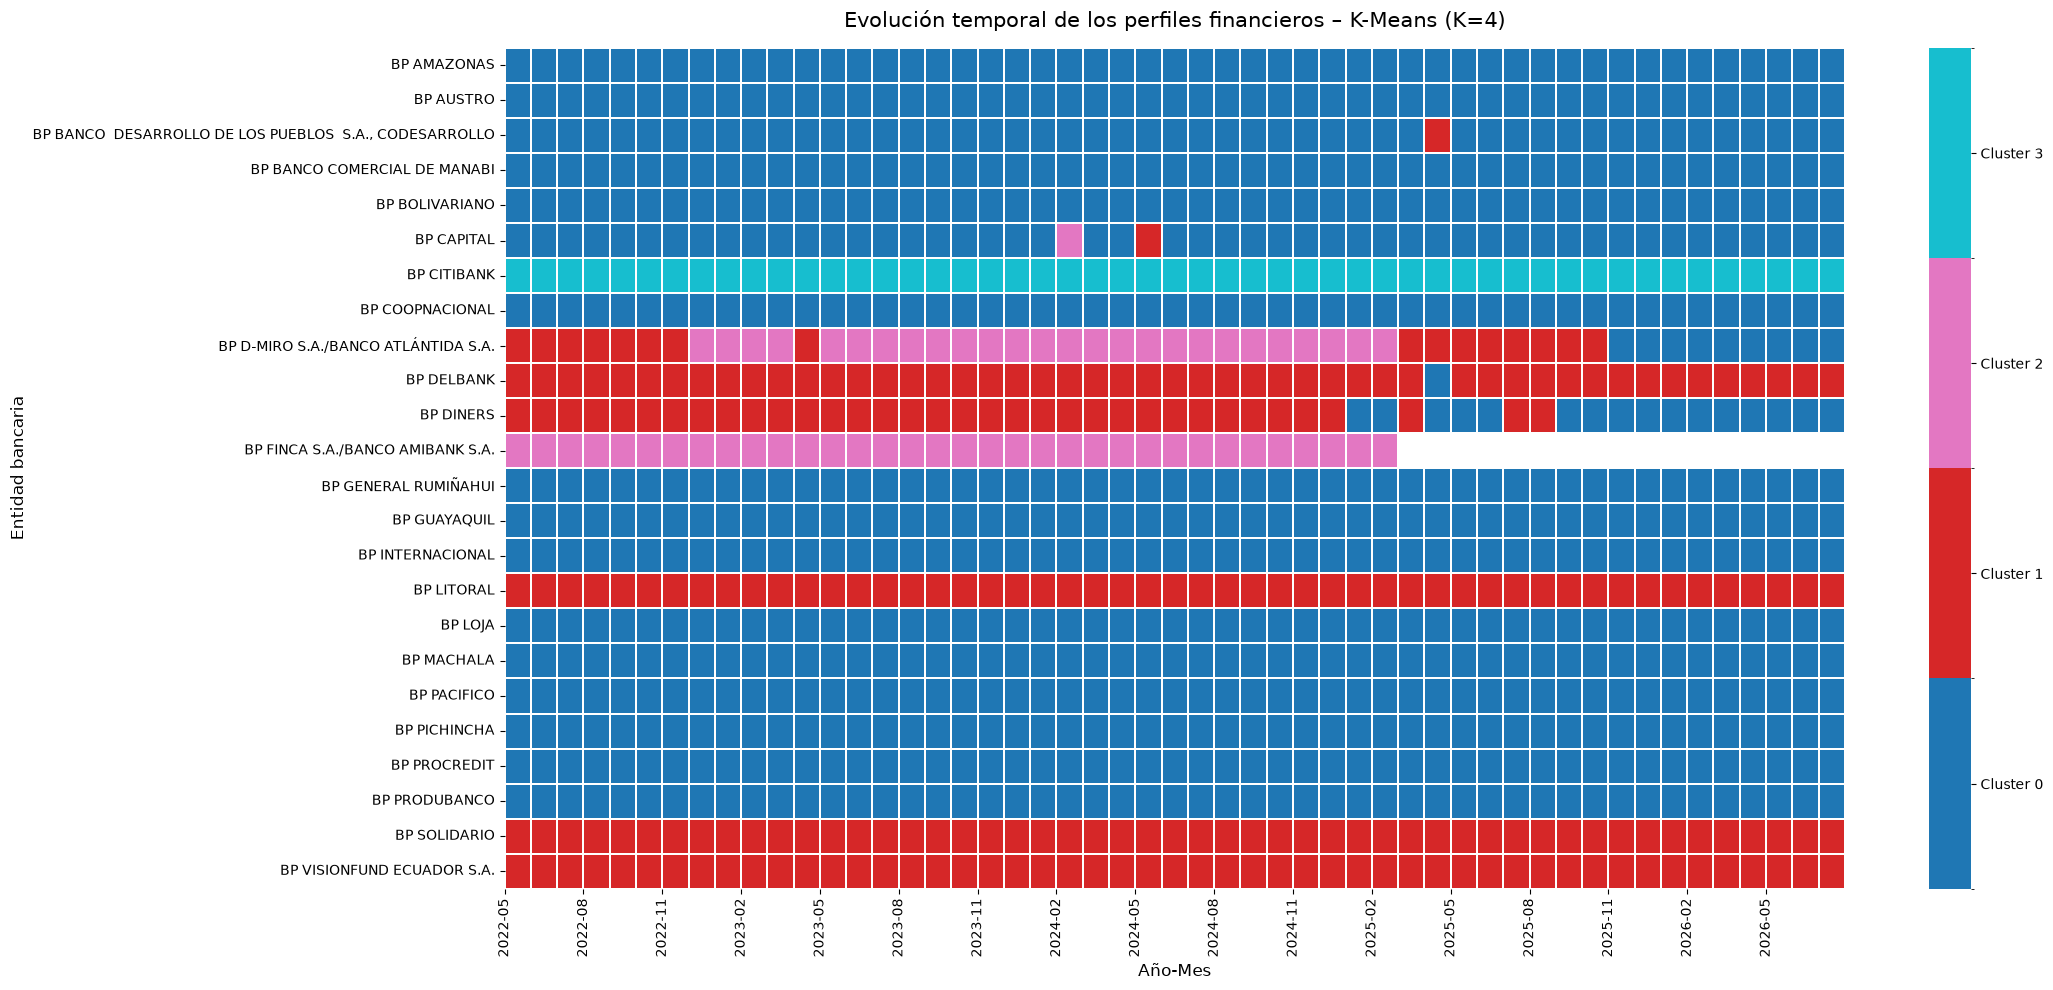

Gráfico guardado en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\cluster_caracterizacion_temporal.png


In [57]:
df_heatmap = base_cluster_k4.copy()

# Asegurar que FECHA sea datetime
df_heatmap["FECHA"] = pd.to_datetime(df_heatmap["FECHA"])

# Orden cronológico
df_heatmap = df_heatmap.sort_values(
    ["FECHA", "ENTIDAD"]
)


matriz_clusters = df_heatmap.pivot(
    index="ENTIDAD",
    columns="FECHA",
    values="CLUSTER"
)


# Un color específico para cada cluster
colores = [
    "#1f77b4",  # Cluster 0
    "#d62728",  # Cluster 1
    "#e377c2",  # Cluster 2
    "#17becf"   # Cluster 3
]

cmap = ListedColormap(colores)

# Límites para que cada color corresponda exactamente
# a un cluster: 0, 1, 2 y 3
norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap.N
)


plt.figure(figsize=(22, 10))

ax = sns.heatmap(
    matriz_clusters,
    cmap=cmap,
    norm=norm,
    cbar=True,
    linewidths=0.2,
    linecolor="white"
)


# Mostrar una etiqueta cada 3 meses
posiciones = range(0, len(matriz_clusters.columns), 3)

etiquetas = [
    fecha.strftime("%Y-%m")
    for fecha in matriz_clusters.columns[posiciones]
]

ax.set_xticks(posiciones)
ax.set_xticklabels(
    etiquetas,
    rotation=90,
    ha="center"
)



colorbar = ax.collections[0].colorbar

colorbar.set_ticks([0, 1, 2, 3])
colorbar.set_ticklabels([
    "Cluster 0",
    "Cluster 1",
    "Cluster 2",
    "Cluster 3"
])


# 7. Títulos y etiquetas

plt.title(
    "Evolución temporal de los perfiles financieros – K-Means (K=4)",
    fontsize=15,
    pad=15
)

plt.xlabel("Año-Mes", fontsize=12)
plt.ylabel("Entidad bancaria", fontsize=12)

plt.tight_layout()

# Guardar como resultado 
ruta_figura = RAIZ_PROYECTO / "results" / "cluster_caracterizacion_temporal.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico guardado en: {ruta_figura.resolve()}")

Las entidades que presentan cambios de clasificación durante el período
analizado son las siguientes:

1. BP D-MIRO S.A. / BANCO ATLÁNTIDA S.A.
   - Diciembre de 2022: Cluster 1 → Cluster 2.
   - Abril de 2023: Cluster 2 → Cluster 1.
   - Mayo de 2023: Cluster 1 → Cluster 2.
   - Marzo de 2025: Cluster 2 → Cluster 1.
   - Noviembre de 2025: Cluster 1 → Cluster 0.

   Esta entidad presenta la mayor movilidad entre perfiles. Inicialmente
   transita entre el Cluster 1, asociado con alta capitalización, liquidez y
   dinamismo, y el Cluster 2, asociado con mayor deterioro crediticio y menor
   rentabilidad. Finalmente, en noviembre de 2025 pasa del Cluster 1 al
   Cluster 0, asociado con un perfil de mayor estabilidad y crecimiento
   moderado, al ser absorbido por el grupo financiero Atlántida el año pasado.

2. BP CAPITAL
   - Febrero de 2024: Cluster 0 → Cluster 2.
   - Marzo de 2024: Cluster 2 → Cluster 0.
   - Mayo de 2024: Cluster 0 → Cluster 1.
   - Junio de 2024: Cluster 1 → Cluster 0.

   Presenta dos episodios puntuales de cambio. En febrero de 2024 pasa
   temporalmente desde un perfil de estabilidad hacia el perfil de mayor
   deterioro, retornando al Cluster 0 al mes siguiente. Posteriormente,
   en mayo de 2024 pasa temporalmente al Cluster 1 y retorna al Cluster 0
   en junio de 2024. En consecuencia, no se observa una transición
   permanente hacia un perfil de mayor deterioro.

3. BP DINERS
   - Enero de 2025: Cluster 1 → Cluster 0.
   - Marzo de 2025: Cluster 0 → Cluster 1.
   - Abril de 2025: Cluster 1 → Cluster 0.
   - Julio de 2025: Cluster 0 → Cluster 1.
   - Septiembre de 2025: Cluster 1 → Cluster 0.

   Presenta varias transiciones entre los Clusters 0 y 1. Su comportamiento
   muestra oscilaciones entre un perfil de alta capitalización, liquidez y
   dinamismo y un perfil de estabilidad y crecimiento moderado. No se
   observa una transición hacia el Cluster 2.

4. BP BANCO DESARROLLO DE LOS PUEBLOS S.A. / CODESARROLLO
   - Abril de 2025: Cluster 0 → Cluster 1.
   - Mayo de 2025: Cluster 1 → Cluster 0.

   El cambio es puntual y transitorio, ya que la entidad retorna al Cluster 0
   inmediatamente después. Por tanto, no se evidencia una modificación
   estructural de su perfil financiero.

5. BP DELBANK
   - Abril de 2025: Cluster 1 → Cluster 0.
   - Mayo de 2025: Cluster 0 → Cluster 1.

   Al igual que Codesarrollo, presenta una transición puntual entre los
   perfiles de alta capitalización y estabilidad, retornando inmediatamente
   al perfil predominante.

### 8.3 Conclusión final del análisis de perfiles financieros



A partir del análisis exploratorio de los indicadores financieros, la reducción
de dimensionalidad mediante PCA y la aplicación de K-Means, se identificaron
cuatro perfiles financieros diferenciados. La selección de la solución final
se realizó utilizando 11 componentes principales (PC11) y cuatro clusters
(K=4), considerando conjuntamente las métricas de calidad del clustering,
la estabilidad de las particiones, el tamaño de los grupos y su
interpretabilidad financiera.

La caracterización final se realizó utilizando los indicadores financieros
originales, estandarizados respecto al promedio y la desviación estándar de
toda la muestra. Esto permitió interpretar las diferencias de cada grupo en
términos financieros y no únicamente desde la perspectiva estadística de los
componentes principales.

De acuerdo con las características identificadas, los perfiles pueden
ordenarse de mejor a peor desempeño financiero relativo de la siguiente
manera:

1. Cluster 3 — Excelente: solidez financiera, calidad crediticia, cobertura y rentabilidad superior.

   Corresponde al perfil con las características financieras más favorables.
   Presenta una cobertura de la cartera problemática significativamente
   superior al promedio, una elevada relación de activos productivos respecto
   de los pasivos con costo, mayor suficiencia patrimonial y rentabilidad
   superior al promedio. Asimismo, presenta una morosidad significativamente
   inferior, menores proporciones de cartera refinanciada y reestructurada y
   menores gastos relativos. En conjunto, representa el perfil de mayor
   solidez financiera y mejor calidad de cartera dentro de los grupos
   identificados.

2. Cluster 0 — Estable: estabilidad, crecimiento moderado y eficiencia relativa.

   Corresponde a entidades con un comportamiento financiero cercano al
   promedio de la muestra, caracterizado por crecimiento moderado de activos
   y patrimonio, rentabilidad ligeramente superior al promedio y menores
   gastos de operación y personal respecto al activo. Asimismo, presenta una
   morosidad inferior al promedio y niveles de cobertura próximos al
   comportamiento general de la muestra. En conjunto, representa un perfil
   relativamente estable, sin desviaciones financieras marcadas y con un
   comportamiento equilibrado entre crecimiento, rentabilidad y eficiencia.

3. Cluster 1 — Alta capitalización: mayor capitalización, liquidez y dinamismo de depósitos, pero mayores gastos y morosidad ligeramente superior.

   Corresponde a entidades que presentan un índice de capitalización neto
   significativamente superior al promedio, acompañado de una mayor relación
   entre cartera bruta y depósitos, mayor disponibilidad de fondos respecto
   de los depósitos a corto plazo y una mayor proporción de activos
   productivos. Asimismo, presentan mayor dinamismo de los depósitos y de los
   fondos disponibles. Sin embargo, registran mayores gastos de operación y
   de personal respecto al activo y una morosidad ligeramente superior al
   promedio. En conjunto, representa un perfil con elevado respaldo
   patrimonial, liquidez e intensidad de intermediación, aunque acompañado
   de mayores costos relativos y un nivel de morosidad algo superior al
   promedio.

4. Cluster 2 — Mayor deterioro: mayor morosidad, menor rentabilidad y menor crecimiento relativo.

   Corresponde al perfil con las características financieras menos favorables.
   Presenta una morosidad significativamente superior al promedio, junto con
   mayores proporciones de cartera refinanciada y reestructurada y mayores
   gastos de personal y operación respecto al activo. En contraste, presenta
   niveles de rentabilidad sobre activos y patrimonio considerablemente
   inferiores al promedio, así como menores niveles de crecimiento de los
   activos, patrimonio y cartera de créditos. También presenta menores niveles
   de activos productivos y un índice de capitalización neto inferior al
   promedio. En conjunto, representa el perfil de mayor deterioro de la
   calidad crediticia, menor rentabilidad y menor dinamismo financiero.

